# Notebook 03 — Entraînement CNN 1D + BiLSTM
## Challenge ENS #45 — Détection d'apnées du sommeil (Dreem)

---

## 1. Introduction & Architecture

### Le problème : segmentation temporelle de signaux PSG

L'objectif du challenge est de détecter, seconde par seconde, les épisodes d'apnée du sommeil à partir d'enregistrements polysomnographiques (PSG) de 90 secondes. Il s'agit d'un **problème de segmentation temporelle** : pour chaque fenêtre d'entrée de 90 s, le modèle doit produire un masque binaire de 90 valeurs indiquant la présence ou l'absence d'apnée à chaque seconde.

Formellement, on cherche à apprendre :

$$f_{\theta} : \mathbb{R}^{8 \times 9000} \longrightarrow [0,1]^{90}$$

### Pourquoi le deep learning ?

Les approches classiques (features manuelles + SVM / Random Forest) nécessitent une extraction experte de caractéristiques : puissance spectrale par bande, envelope du flux nasal, variance de la SpO₂, etc. Ces features sont fragiles face à la variabilité inter-sujets (taux d'apnée de 0.74% à 27.24% selon les sujets) et n'exploitent pas les **dépendances temporelles multi-échelles** entre signaux. Un CNN 1D apprend automatiquement les filtres optimaux ; un BiLSTM modélise le contexte séquentiel entre les secondes.

### Architecture choisie : CNN 1D + BiLSTM

**Encodeur CNN 1D — extraction de patterns locaux.**
Les apnées se manifestent par des patterns répétitifs et reconnaissables : chute du flux nasal (AirFlow), efforts thoraciques et abdominaux compensatoires (ThorBelt, AbdoBelt), désaturation SpO₂ avec délai de ~15-20 s. Ces patterns ont une structure locale (durée typique 17 s = 1700 points à 100 Hz) bien adaptée aux convolutions 1D. L'encodeur réduit la séquence de **9000 → 90 points** (facteur ×100 exact), transformant chaque point de sortie en un résumé d'une seconde de signal.

**BiLSTM — contexte temporel entre secondes.**
Une apnée isolée de 17 s dans une nuit de sommeil calme n'a pas le même profile qu'une apnée dans une série de 10 consécutives. Le BiLSTM capture ces **dépendances à longue portée** entre secondes (contexte passé via LSTM forward, futur via LSTM backward), ce qui améliore la précision aux bornes des événements.

**Tête de classification.**
Une couche `Linear(128, 1)` appliquée indépendamment sur chaque timestep produit les logits bruts. `BCEWithLogitsLoss` s'occupe de la sigmoïde — cette décomposition est numériquement plus stable qu'appliquer sigmoid puis BCELoss.

### Schéma ASCII de l'architecture

```
Input : (batch, 8, 9000)    — 8 canaux PSG, 9000 points @ 100 Hz
         │
         ▼
┌─────────────────────────────────────────────────────────┐
│  ENCODEUR CNN 1D                                        │
│                                                         │
│  Conv1d(8→32,   k=11, stride=5) + BN + ReLU            │
│  → (batch, 32, 1800)                                    │
│                                                         │
│  Conv1d(32→64,  k=9,  stride=5) + BN + ReLU            │
│  → (batch, 64, 360)                                     │
│                                                         │
│  Conv1d(64→128, k=5,  stride=4) + BN + ReLU            │
│  → (batch, 128, 90)          [réduction ×100 exacte]   │
└─────────────────────────────────────────────────────────┘
         │
         ▼  permute(0,2,1)
         │
         ▼  (batch, 90, 128)
┌─────────────────────────────────────────────────────────┐
│  BiLSTM                                                 │
│  hidden=64, layers=2, bidirectional, dropout=0.3        │
│  → (batch, 90, 128)    [64 × 2 directions]              │
│  + Dropout(0.3)                                         │
└─────────────────────────────────────────────────────────┘
         │
         ▼
┌─────────────────────────────────────────────────────────┐
│  TÊTE DE CLASSIFICATION                                 │
│  Linear(128, 1) → squeeze → (batch, 90)                 │
│  logits bruts (sigmoid implicite dans la loss)          │
└─────────────────────────────────────────────────────────┘
         │
         ▼
Output : (batch, 90)   — un logit par seconde
```

### Biais de validation et implications

Le split par sujet du notebook 02 a affecté les sujets `{0, 1, 8, 13, 15}` à la validation. Ces sujets présentent des taux d'apnée de 0.99%, 2.90%, 13.77%, 1.63% et 3.41% respectivement — tous inférieurs à la moyenne du train. **Le F1 de validation sera donc optimiste** : le modèle sera évalué sur des cas plus faciles que la distribution réelle du test. Il ne faut pas sur-interpréter un F1_val élevé. La solution correcte est une cross-validation GroupKFold (section 13).

---

---

## 2. Setup & Configuration

Le flag `IS_KAGGLE` permet de basculer entre l'environnement local (chemins relatifs depuis `notebooks/`) et l'environnement Kaggle (données uploadées dans `/kaggle/input/`). Pour soumettre sur Kaggle, seul ce flag doit changer.

---

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy.ndimage import median_filter
warnings.filterwarnings('ignore')
print(f"PyTorch version : {torch.__version__}")
print(f"NumPy   version : {np.__version__}")

PyTorch version : 2.10.0+cu128
NumPy   version : 2.0.2


In [2]:
# ── Configuration des chemins ──────────────────────────────────────────────────
# IS_KAGGLE = True  : exécution sur Kaggle (dataset 'dreem-processed' monté)
# IS_KAGGLE = False : exécution locale depuis notebooks/
IS_KAGGLE = True

if IS_KAGGLE:
    DATA_DIR    = Path('/kaggle/input/datasets/tholinale/dreem-processed/')
    RAW_DIR     = Path('/kaggle/input/datasets/tholinale/dreem-processed/')
    OUTPUT_DIR  = Path('/kaggle/working/')
    FIGURES_DIR = Path('/kaggle/working/figures/')
else:
    DATA_DIR    = Path('../data/processed/')
    RAW_DIR     = Path('../data/raw/')
    OUTPUT_DIR  = Path('../data/submissions/')
    FIGURES_DIR = Path('../figures/')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"IS_KAGGLE   : {IS_KAGGLE}")
print(f"DATA_DIR    : {DATA_DIR}")
print(f"RAW_DIR     : {RAW_DIR}")
print(f"OUTPUT_DIR  : {OUTPUT_DIR}")
print(f"FIGURES_DIR : {FIGURES_DIR}")

IS_KAGGLE   : True
DATA_DIR    : /kaggle/input/datasets/tholinale/dreem-processed
RAW_DIR     : /kaggle/input/datasets/tholinale/dreem-processed
OUTPUT_DIR  : /kaggle/working
FIGURES_DIR : /kaggle/working/figures


In [3]:
# ── Constantes du projet (reproduites depuis config.py pour autonomie Kaggle) ──
RANDOM_SEED          = 42
N_SIGNALS            = 8
N_SAMPLES_PER_SIGNAL = 9000    # 90 s × 100 Hz
N_LABEL_COLS         = 90      # une étiquette par seconde
SIGNAL_FREQ          = 100     # Hz
WINDOW_SECS          = 90

# Hyperparamètres d'entraînement
BATCH_SIZE    = 32
MAX_EPOCHS    = 60
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 15
MEDIAN_KERNEL_SIZES = [3, 5, 7]

# Déséquilibre de classes mesuré sur X_train (notebook 02, section 6).
# pos_weight = n_négatifs / n_positifs = 282872 / 23128 = 12.23
# Sur le split train uniquement (3400 fenêtres, 17 sujets).
POS_WEIGHT = 12.23

SIGNAL_NAMES = [
    'AbdoBelt', 'AirFlow', 'PPG', 'ThorBelt',
    'Snoring', 'SpO2', 'EEG C4-A1', 'EEG O2-A1'
]

# ── Reproductibilité ──────────────────────────────────────────────────────────
def set_seed(seed: int = RANDOM_SEED):
    """Fixe toutes les sources d'aléatoire pour la reproductibilité."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)
print(f"Seed fixé : {RANDOM_SEED}")

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice : {device}")

if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU     : {gpu_name}")
    print(f"  Mémoire : {gpu_mem:.1f} Go")
    print(f"  CUDA    : {torch.version.cuda}")
else:
    print("  Pas de GPU détecté — entraînement sur CPU (lent).")
    print("  → Sur Kaggle, activer l'accélérateur GPU dans les paramètres du notebook.")

Seed fixé : 42

Device : cuda
  GPU     : Tesla T4
  Mémoire : 15.6 Go
  CUDA    : 12.8


---

## 3. Chargement lazy des données

### Pourquoi le lazy loading ?

Les fichiers `.npy` produits par le notebook 02 totalisent **2.5 Go**. Charger l'intégralité en RAM avec `np.load()` serait possible sur une machine locale avec suffisamment de mémoire, mais rédhibitoire sur Kaggle (RAM limitée à 13-16 Go partagée avec PyTorch et les tenseurs GPU).

`np.load(..., mmap_mode='r')` ouvre le fichier en **lecture mappée en mémoire** (*memory-mapped I/O*) : le tableau numpy est créé sans copier les données en RAM. Les données ne sont chargées que page par page, au moment où elles sont accédées. Pour un DataLoader avec `__getitem__`, cela signifie que seules les lignes demandées par le batch sont lues depuis le disque — exactement ce qu'il faut.

> **Note importante :** `np.load(..., mmap_mode='r')` gère automatiquement l'en-tête `.npy` (magic number, dtype, shape). C'est l'API correcte pour mapper des fichiers `.npy` — `np.memmap` brut nécessiterait de calculer manuellement l'offset de l'en-tête.

---

In [4]:
import tracemalloc

# ── Chargement via memory-map (lazy) — X ne charge PAS en RAM ─────────────────
tracemalloc.start()

print("Ouverture des fichiers en mode memory-mapped (mmap_mode='r') ...")

X_train = np.load(DATA_DIR / 'X_train_processed.npy', mmap_mode='r')  # (3400, 8, 9000)
X_val   = np.load(DATA_DIR / 'X_val_processed.npy',   mmap_mode='r')  # (1000, 8, 9000)
X_test  = np.load(DATA_DIR / 'X_test_processed.npy',  mmap_mode='r')  # (4400, 8, 9000)

# ── Labels — légers, chargement normal en RAM ──────────────────────────────────
y_train = np.load(DATA_DIR / 'y_train_processed.npy')  # (3400, 90)
y_val   = np.load(DATA_DIR / 'y_val_processed.npy')    # (1000, 90)

# Indices pour traçabilité
#train_idx = np.load(DATA_DIR / 'train_idx.npy')
#val_idx   = np.load(DATA_DIR / 'val_idx.npy')

# Mémoire allouée APRÈS l'ouverture des memmaps (doit rester faible)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"\nShapes chargées :")
print(f"  X_train : {X_train.shape}  dtype={X_train.dtype}  (sur disque: ~979 Mo)")
print(f"  X_val   : {X_val.shape}   dtype={X_val.dtype}  (sur disque: ~288 Mo)")
print(f"  X_test  : {X_test.shape}  dtype={X_test.dtype}  (sur disque: ~1267 Mo)")
print(f"  y_train : {y_train.shape}  dtype={y_train.dtype}")
print(f"  y_val   : {y_val.shape}   dtype={y_val.dtype}")
print(f"\nMémoire allouée pour l'ouverture des memmaps : {current / 1e6:.1f} Mo")
print(f"(les 2.5 Go de données restent sur disque jusqu'au __getitem__)")

Ouverture des fichiers en mode memory-mapped (mmap_mode='r') ...

Shapes chargées :
  X_train : (3400, 8, 9000)  dtype=float32  (sur disque: ~979 Mo)
  X_val   : (1000, 8, 9000)   dtype=float32  (sur disque: ~288 Mo)
  X_test  : (4400, 8, 9000)  dtype=float32  (sur disque: ~1267 Mo)
  y_train : (3400, 90)  dtype=float32
  y_val   : (1000, 90)   dtype=float32

Mémoire allouée pour l'ouverture des memmaps : 1.6 Mo
(les 2.5 Go de données restent sur disque jusqu'au __getitem__)


In [5]:
# ── Récupération des IDs du test pour la soumission ───────────────────────────
import h5py

# IDs test extraits directement du .npy (X_test.h5 non uploadé sur Kaggle)
test_ids = np.arange(4400, 8800)  # IDs réels : 4400–8799 (vérifiés sur y_benchmark.csv)
print(f"test_ids : {test_ids.shape} — de {test_ids[0]} à {test_ids[-1]}  ← IDs benchmark")

print(f"  test_ids : shape={test_ids.shape}, min={test_ids.min()}, max={test_ids.max()}")
assert len(test_ids) == X_test.shape[0], "Incohérence entre X_test et test_ids"
print("OK")

test_ids : (4400,) — de 4400 à 8799  ← IDs benchmark
  test_ids : shape=(4400,), min=4400, max=8799
OK


---

## 4. Dataset & DataLoader PyTorch

### Design du `DreemDataset`

La classe `DreemDataset` encapsule le tableau memory-mapped et expose l'interface `__getitem__` attendue par PyTorch. Deux points critiques :

1. **`.copy()` sur les slices memmap.** Un tableau `np.memmap` retourne des *vues* sur les données disque. `torch.from_numpy()` exige un tableau contigu en mémoire avec ownership exclusif — l'appel `.copy()` matérialise la copie d'une seule ligne en RAM avant la conversion en tenseur. Sans `.copy()`, PyTorch lèverait une `RuntimeError`.

2. **`y=None` pour le test set.** Le dataset de test n'a pas de labels. En passant `y=None`, `__getitem__` ne retourne que `X`, ce qui simplifie la boucle d'inférence sans dupliquer le code.

### `pin_memory=True`

Sur GPU, le transfert de données CPU → GPU se fait via PCIe. La mémoire paginable (heap Python normal) doit être re-copiée dans une zone de mémoire physiquement fixe (*pinned memory*) avant le transfert DMA. Avec `pin_memory=True`, le DataLoader pré-alloue directement les batches en mémoire *pinned*, **éliminant cette copie intermédiaire** et accélérant le transfert d'environ 20-40%.

> Sur CPU uniquement, `pin_memory=True` n'apporte rien et peut légèrement ralentir — le code le désactive automatiquement si `device == 'cpu'`.

---

---

## Amélioration 3 — Augmentation de données

### Motivation : régularisation implicite sur 22 sujets

Le jeu d'entraînement ne contient que **17 sujets** (après split 80/20), soit une diversité physiologique extrêmement limitée. La variabilité inter-sujets du taux d'apnée atteint un facteur ×37 (0.3 % à 33.5 %), ce qui rend le modèle vulnérable à la **mémorisation** des patterns individuels (*overfitting subject-level*).

L'augmentation de données crée des **variantes synthétiques** de chaque fenêtre à chaque epoch, augmentant la diversité effective d'entraînement sans nouveaux sujets. Trois transformations sont appliquées :

| Augmentation | Paramètres | Justification clinique |
|---|---|---|
| **Bruit gaussien** | `σ = 0.05` (après normalisation z-score) | Modélise le bruit électronique des capteurs PSG |
| **Time shift aléatoire** | `±50 échantillons = ±0.5 s` | Variabilité de la fenêtrage temporel entre nuits |
| **Channel dropout** | `p = 0.1` par canal | Simule les artefacts de mouvement et électrodes décrochées |

Ces transformations sont **désactivées en validation et test** (`augment=False`) pour garantir une évaluation honnête.

> *Référence : Shorten & Khoshgoftaar (2019). "A survey on image data augmentation for deep learning." Journal of Big Data, 6(60).*

---

In [6]:
class DreemDataset(Dataset):
    """
    Dataset PyTorch pour les signaux PSG du challenge Dreem.

    Paramètres
    ----------
    X       : np.ndarray ou np.memmap, shape (N, 8, 9000)
        Signaux normalisés. Peut être un tableau memory-mapped.
    y       : np.ndarray ou None, shape (N, 90)
        Labels binaires (seconde par seconde). None pour le test set.
    augment : bool — active l'augmentation (train uniquement, défaut False)
        - Bruit gaussien additif (σ=0.05)
        - Time shift aléatoire (±50 échantillons)
        - Channel dropout (p=0.1 par canal)

    Notes
    -----
    Le `.copy()` dans __getitem__ est obligatoire quand X est un memmap :
    torch.from_numpy() exige un tableau C-contigu avec ownership exclusif.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray = None, augment: bool = False):
        self.X       = X
        self.y       = y
        self.augment = augment
        self.has_labels = y is not None

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        # .copy() : matérialise la ligne depuis le memmap en RAM contiguë
        x = self.X[idx].copy()   # (8, 9000) float32 — numpy array

        if self.augment:
            # ── Bruit gaussien additif (σ=0.05) ────────────────────────────
            x = x + np.random.normal(0, 0.05, x.shape).astype(np.float32)
            # ── Time shift aléatoire (±50 échantillons = ±0.5 s) ──────────
            shift = int(np.random.randint(-50, 51))
            x = np.roll(x, shift=shift, axis=-1)
            # ── Channel dropout (p=0.1 par canal) ─────────────────────────
            for c in range(x.shape[0]):
                if np.random.random() < 0.1:
                    x[c] = 0.0

        x = torch.from_numpy(x)   # (8, 9000) float32
        if self.has_labels:
            y = torch.from_numpy(self.y[idx].copy())   # (90,) float32
            return x, y
        return x


# ── Instanciation des datasets ─────────────────────────────────────────────────
ds_train = DreemDataset(X_train, y_train, augment=True)
ds_val   = DreemDataset(X_val,   y_val,   augment=False)
ds_test  = DreemDataset(X_test,  y=None,  augment=False)

print(f"DreemDataset créés :")
print(f"  Train : {len(ds_train)} samples")
print(f"  Val   : {len(ds_val)} samples")
print(f"  Test  : {len(ds_test)} samples")

# Vérification d'un __getitem__
x_sample, y_sample = ds_train[0]
print(f"\nTest __getitem__(0) :")
print(f"  x shape  : {x_sample.shape}  dtype={x_sample.dtype}")
print(f"  y shape  : {y_sample.shape}  dtype={y_sample.dtype}")
print(f"  y values : {y_sample[:10].numpy()}  ...")

DreemDataset créés :
  Train : 3400 samples
  Val   : 1000 samples
  Test  : 4400 samples

Test __getitem__(0) :
  x shape  : torch.Size([8, 9000])  dtype=torch.float32
  y shape  : torch.Size([90])  dtype=torch.float32
  y values : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]  ...


In [7]:
# ── DataLoaders ────────────────────────────────────────────────────────────────
# pin_memory=True uniquement si GPU disponible (inutile sur CPU)
_pin = (device.type == 'cuda')
# num_workers=0 sur Windows (multiprocessing incompatible avec memmap dans certains contextes)
_workers = 0 if os.name == 'nt' else 2

loader_train = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,             # mélanger les fenêtres à chaque epoch
    num_workers=_workers,
    pin_memory=_pin,
    drop_last=True            # éviter les batches incomplets qui perturbent BatchNorm
)

loader_val = DataLoader(
    ds_val,
    batch_size=64,            # batch plus grand en val (pas de gradient, moins de VRAM)
    shuffle=False,
    num_workers=_workers,
    pin_memory=_pin
)

loader_test = DataLoader(
    ds_test,
    batch_size=64,
    shuffle=False,
    num_workers=_workers,
    pin_memory=_pin
)

print(f"DataLoaders créés (pin_memory={_pin}, num_workers={_workers}) :")
print(f"  Train : {len(loader_train)} batches de {BATCH_SIZE}")
print(f"  Val   : {len(loader_val)} batches de 64")
print(f"  Test  : {len(loader_test)} batches de 64")

# Vérification d'un batch
xb, yb = next(iter(loader_train))
print(f"\nBatch exemple — X: {xb.shape}, y: {yb.shape}")

DataLoaders créés (pin_memory=True, num_workers=2) :
  Train : 106 batches de 32
  Val   : 16 batches de 64
  Test  : 69 batches de 64

Batch exemple — X: torch.Size([32, 8, 9000]), y: torch.Size([32, 90])


---

## 5. Architecture DreemNet

### Vérification de la réduction temporelle ×100

La contrainte centrale de l'architecture est que la sortie du CNN doit avoir **exactement 90 timesteps** pour correspondre aux 90 labels. On vérifie analytiquement :

Pour une Conv1d avec `(L_in, kernel, stride, padding)`, la formule de la longueur de sortie est :
$$L_{out} = \left\lfloor \frac{L_{in} + 2 \cdot \text{padding} - \text{kernel}}{\text{stride}} \right\rfloor + 1$$

| Bloc | $L_{in}$ | kernel | stride | padding | $L_{out}$ |
|------|---------|--------|--------|---------|----------|
| Conv1 | 9000 | 11 | 5 | 5 | $\lfloor(9000+10-11)/5\rfloor+1 = 1800$ |
| Conv2 | 1800 | 9  | 5 | 4 | $\lfloor(1800+8-9)/5\rfloor+1 = 360$ |
| Conv3 | 360  | 5  | 4 | 2 | $\lfloor(360+4-5)/4\rfloor+1 = 90$ |

Réduction totale : $9000 / 90 = \times 100$ ✓

### Dropout dans le BiLSTM

Le paramètre `dropout` du BiLSTM s'applique entre les couches cachées (sur les connexions entre les 2 couches LSTM), **pas** sur la sortie finale. On ajoute un `Dropout(0.3)` explicite après le BiLSTM pour régulariser la connexion vers la tête linéaire.

---

---

## Amélioration 4 — Architecture DreemNetV2 : CNN + Transformer Temporel

### Limitations du BiLSTM face aux dépendances longue portée

Le BiLSTM traite les 90 timesteps **séquentiellement** : pour capturer la corrélation entre la seconde 5 et la seconde 70, l'information doit traverser 65 états cachés successifs. Ce chemin long induit un **gradient vanishing** partiel malgré l'architecture bidirectionnelle, limitant la modélisation des structures globales (cycles d'apnée récurrents, alternances NREM/REM).

### Mécanisme d'auto-attention : dépendances O(1)

Le **Transformer** (Vaswani et al., 2017) calcule directement la similarité entre chaque paire de timesteps :

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Chaque seconde peut « voir » n'importe quelle autre seconde en **O(1)** opérations, indépendamment de leur distance. Sur 90 timesteps, les dépendances physiologiques (la SpO₂ chute 15–20 s après l'occlusion des voies aériennes) sont modélisées sans dégradation du gradient.

Le **positional encoding sinusoïdal** injecte l'information de position temporelle dans l'espace latent :

$$PE(\text{pos}, 2i) = \sin\!\left(\frac{\text{pos}}{10000^{2i/d_{\text{model}}}}\right), \quad PE(\text{pos}, 2i+1) = \cos\!\left(\frac{\text{pos}}{10000^{2i/d_{\text{model}}}}\right)$$

### Comparaison architecturale

| Critère | DreemNet (BiLSTM) | DreemNetV2 (Transformer) |
|---|---|---|
| Dépendances longue portée | ✗ Atténuées | ✓ Directes O(1) |
| Parallélisation GPU | ✗ Séquentielle | ✓ Complète |
| Paramètres | ~340 K | ~430 K |
| Complexité | O(T · d²) | O(T² · d) — négligeable pour T=90 |

> *Référence : Vaswani et al. (2017). "Attention is all you need." NeurIPS 2017.*

---

In [8]:
class ConvBlock(nn.Module):
    """Bloc Conv1d + BatchNorm1d + ReLU réutilisable."""

    def __init__(self, in_channels: int, out_channels: int,
                 kernel_size: int, stride: int, padding: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels,
                      kernel_size=kernel_size, stride=stride,
                      padding=padding, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class DreemNet(nn.Module):
    """
    Architecture CNN 1D + BiLSTM pour la segmentation temporelle d'apnées.

    Flux des données :
        (batch, 8, 9000)
        → CNN encoder : (batch, 128, 90)   [réduction ×100 exacte]
        → permute     : (batch, 90, 128)
        → BiLSTM      : (batch, 90, 128)   [64 × 2 directions]
        → Dropout
        → Linear      : (batch, 90, 1)
        → squeeze     : (batch, 90)        [logits bruts]

    Paramètres
    ----------
    n_channels   : int — nombre de canaux d'entrée (8)
    cnn_channels : list[int] — filtres par bloc CNN ([32, 64, 128])
    lstm_hidden  : int — taille de l'état caché LSTM par direction (64)
    lstm_layers  : int — nombre de couches LSTM empilées (2)
    dropout      : float — taux de dropout dans LSTM et avant la tête (0.3)
    """

    def __init__(
        self,
        n_channels: int = 8,
        cnn_channels: list = None,
        lstm_hidden: int = 64,
        lstm_layers: int = 2,
        dropout: float = 0.3
    ):
        super().__init__()
        if cnn_channels is None:
            cnn_channels = [32, 64, 128]

        # ── Encodeur CNN 1D ────────────────────────────────────────────────────
        # Réduction temporelle exacte ×100 : 9000 → 1800 → 360 → 90
        # Chaque ConvBlock : (in_ch, out_ch, kernel, stride, padding)
        self.encoder = nn.Sequential(
            ConvBlock(n_channels,         cnn_channels[0], 11, stride=5, padding=5),
            ConvBlock(cnn_channels[0],    cnn_channels[1],  9, stride=5, padding=4),
            ConvBlock(cnn_channels[1],    cnn_channels[2],  5, stride=4, padding=2),
        )

        # ── BiLSTM ─────────────────────────────────────────────────────────────
        # input_size = cnn_channels[-1] = 128
        # output par timestep = lstm_hidden * 2 (bidirectionnel) = 128
        self.bilstm = nn.LSTM(
            input_size=cnn_channels[-1],
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)

        # ── Tête de classification ─────────────────────────────────────────────
        # lstm_hidden * 2 directions = 128
        self.classifier = nn.Linear(lstm_hidden * 2, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Paramètres
        ----------
        x : (batch, 8, 9000)

        Retourne
        --------
        logits : (batch, 90) — logits bruts (pas de sigmoid)
        """
        # Encodage CNN : (batch, 8, 9000) → (batch, 128, 90)
        x = self.encoder(x)

        # Permutation pour le BiLSTM : (batch, 128, 90) → (batch, 90, 128)
        x = x.permute(0, 2, 1)

        # BiLSTM : (batch, 90, 128) → (batch, 90, 128)
        x, _ = self.bilstm(x)
        x = self.dropout(x)

        # Classification : (batch, 90, 128) → (batch, 90, 1) → (batch, 90)
        x = self.classifier(x).squeeze(-1)
        return x


print("Classe DreemNet définie.")

Classe DreemNet définie.


In [9]:
import math

class PositionalEncoding(nn.Module):
    """
    Positional encoding sinusoïdal (Vaswani et al., 2017).

    Injecte l'information de position temporelle dans l'espace latent :
        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Paramètres
    ----------
    d_model : int — dimension du vecteur de représentation
    max_len : int — longueur maximale de la séquence (90 pour ce dataset)
    dropout : float — taux de dropout appliqué après le PE
    """

    def __init__(self, d_model: int, max_len: int = 90, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x : (batch, seq_len, d_model)"""
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class DreemNetV2(nn.Module):
    """
    Architecture CNN 1D + Transformer Temporel pour la segmentation d'apnées.

    Flux des données :
        (batch, 8, 9000)
        → CNN encoder identique DreemNet : (batch, 128, 90)  [réduction ×100]
        → permute              : (batch, 90, 128)
        → Positional Encoding  : (batch, 90, 128)
        → TransformerEncoder   : (batch, 90, 128)  [2 couches, 8 têtes, FFN=256]
        → Linear               : (batch, 90, 1)
        → squeeze              : (batch, 90)        [logits bruts]

    Paramètres
    ----------
    n_channels      : int — canaux d'entrée (8)
    cnn_channels    : list[int] — filtres CNN ([32, 64, 128])
    d_model         : int — dimension Transformer = sortie CNN (128)
    nhead           : int — têtes d'attention (8)
    num_layers      : int — couches TransformerEncoder (2)
    dim_feedforward : int — dimension FFN interne (256)
    dropout         : float — taux de dropout (0.1)
    """

    def __init__(
        self,
        n_channels: int = 8,
        cnn_channels: list = None,
        d_model: int = 128,
        nhead: int = 8,
        num_layers: int = 2,
        dim_feedforward: int = 256,
        dropout: float = 0.1
    ):
        super().__init__()
        if cnn_channels is None:
            cnn_channels = [32, 64, 128]

        # ── Encodeur CNN 1D (identique à DreemNet) ────────────────────────────
        # Réduction ×100 : 9000 → 1800 → 360 → 90
        self.encoder = nn.Sequential(
            ConvBlock(n_channels,         cnn_channels[0], 11, stride=5, padding=5),
            ConvBlock(cnn_channels[0],    cnn_channels[1],  9, stride=5, padding=4),
            ConvBlock(cnn_channels[1],    cnn_channels[2],  5, stride=4, padding=2),
        )

        # ── Positional Encoding sinusoïdal ────────────────────────────────────
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=90,
                                               dropout=dropout)

        # ── TransformerEncoder : 2 couches, 8 têtes, FFN=256 ─────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True          # Pre-LN : stabilise l'entraînement
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=num_layers)

        # ── Tête de classification ─────────────────────────────────────────────
        self.classifier = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Paramètres
        ----------
        x : (batch, 8, 9000)

        Retourne
        --------
        logits : (batch, 90) — logits bruts (pas de sigmoid)
        """
        # CNN : (batch, 8, 9000) → (batch, 128, 90)
        x = self.encoder(x)

        # Permutation pour le Transformer : (batch, 128, 90) → (batch, 90, 128)
        x = x.permute(0, 2, 1)

        # Positional Encoding
        x = self.pos_encoder(x)

        # Transformer : (batch, 90, 128) → (batch, 90, 128)
        x = self.transformer(x)

        # Classification : (batch, 90, 128) → (batch, 90)
        x = self.classifier(x).squeeze(-1)
        return x


# ── Test rapide DreemNetV2 ─────────────────────────────────────────────────────
model_v2_test = DreemNetV2()
dummy = torch.zeros(2, 8, 9000)
out_v2 = model_v2_test(dummy)
assert out_v2.shape == (2, 90), f"Shape inattendue : {out_v2.shape}"

n_params_v2 = sum(p.numel() for p in model_v2_test.parameters() if p.requires_grad)
n_params_v1 = sum(p.numel() for p in DreemNet().parameters() if p.requires_grad)
print("Classe DreemNetV2 définie.")
print(f"  DreemNet v1  (BiLSTM)      : {n_params_v1:,} paramètres")
print(f"  DreemNetV2   (Transformer) : {n_params_v2:,} paramètres")
print(f"  Output shape : {out_v2.shape}  ✓")
del model_v2_test

Classe DreemNetV2 définie.
  DreemNet v1  (BiLSTM)      : 261,441 paramètres
  DreemNetV2   (Transformer) : 327,745 paramètres
  Output shape : torch.Size([2, 90])  ✓


In [10]:
import torch

# Forcer CPU si erreur CUDA kernel
try:
    # Test rapide pour vérifier que le GPU fonctionne vraiment
    torch.zeros(1).cuda()
    device = torch.device('cuda')
    print(f"GPU OK : {torch.cuda.get_device_name(0)}")
except Exception as e:
    print(f"GPU non disponible ({e.__class__.__name__}), bascule sur CPU")
    device = torch.device('cpu')

print(f"Device utilisé : {device}")

GPU OK : Tesla T4
Device utilisé : cuda


In [11]:
# Désactiver cuDNN pour compatibilité (résout le kernel image error)
torch.backends.cudnn.enabled = False

In [12]:
# ── Instanciation & inspection ─────────────────────────────────────────────────
model = DreemNet(
    n_channels=N_SIGNALS,
    cnn_channels=[32, 64, 128],
    lstm_hidden=64,
    lstm_layers=2,
    dropout=0.3
).to(device)

print("Architecture DreemNet :")
print(model)
print()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux     : {total_params:,}")
print(f"Paramètres entraînable: {trainable_params:,}")
print(f"Mémoire modèle (fp32) : {total_params * 4 / 1e6:.1f} Mo")

Architecture DreemNet :
DreemNet(
  (encoder): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv1d(8, 32, kernel_size=(11,), stride=(5,), padding=(5,), bias=False)
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv1d(32, 64, kernel_size=(9,), stride=(5,), padding=(4,), bias=False)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv1d(64, 128, kernel_size=(5,), stride=(4,), padding=(2,), bias=False)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
  )
  (bilstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inp

In [13]:
# ── Test du forward pass — vérification des shapes ────────────────────────────
print("Test forward pass avec batch fictif (batch=2) ...")

model.eval()
with torch.no_grad():
    x_dummy = torch.randn(2, N_SIGNALS, N_SAMPLES_PER_SIGNAL).to(device)
    print(f"  Input  : {tuple(x_dummy.shape)}")

    # Inspection intermédiaire étape par étape
    out_enc = model.encoder(x_dummy)
    print(f"  Après encoder CNN : {tuple(out_enc.shape)}")

    out_perm = out_enc.permute(0, 2, 1)
    print(f"  Après permute     : {tuple(out_perm.shape)}")

    out_lstm, _ = model.bilstm(out_perm)
    print(f"  Après BiLSTM      : {tuple(out_lstm.shape)}")

    out_logits = model(x_dummy)
    print(f"  Output (logits)   : {tuple(out_logits.shape)}")

# Vérification critique : réduction exactement ×100
assert out_enc.shape[2] == N_LABEL_COLS, (
    f"La sortie CNN doit avoir {N_LABEL_COLS} timesteps, "
    f"obtenu {out_enc.shape[2]}. Vérifier les strides."
)
assert out_logits.shape == (2, N_LABEL_COLS), (
    f"Output attendu (2, {N_LABEL_COLS}), obtenu {out_logits.shape}"
)

print(f"\nAssert réduction ×100 : 9000 → {out_enc.shape[2]} ✓")
print(f"Assert output shape   : {tuple(out_logits.shape)} ✓")
model.train()

Test forward pass avec batch fictif (batch=2) ...
  Input  : (2, 8, 9000)
  Après encoder CNN : (2, 128, 90)
  Après permute     : (2, 90, 128)
  Après BiLSTM      : (2, 90, 128)
  Output (logits)   : (2, 90)

Assert réduction ×100 : 9000 → 90 ✓
Assert output shape   : (2, 90) ✓


DreemNet(
  (encoder): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv1d(8, 32, kernel_size=(11,), stride=(5,), padding=(5,), bias=False)
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv1d(32, 64, kernel_size=(9,), stride=(5,), padding=(4,), bias=False)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv1d(64, 128, kernel_size=(5,), stride=(4,), padding=(2,), bias=False)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
  )
  (bilstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifie

---

## 6. Loss, Optimiseur & Scheduler

### BCEWithLogitsLoss et pos_weight

`BCEWithLogitsLoss` combine sigmoid et cross-entropy binaire en une seule opération, plus stable numériquement (évite les overflow de `sigmoid(x)` pour `x >> 0`). Le paramètre `pos_weight = 12.23` a été calculé sur le split train uniquement (notebook 02, section 6) :
$$w^+ = \frac{N_{\text{négatifs}}}{N_{\text{positifs}}} = \frac{282\,872}{23\,128} = 12.23$$
Chaque seconde d'apnée contribue 12.23× plus à la perte qu'une seconde normale, compensant le déséquilibre 12.2:1 sans sous-échantillonnage ni suréchantillonnage des données.

### Adam avec weight_decay

Le jeu d'entraînement ne compte que 17 sujets (3400 fenêtres). Dans ce régime de données limitées, la régularisation L2 via `weight_decay=1e-4` pénalise les poids larges et réduit le risque de sur-apprentissage des patterns spécifiques aux sujets d'entraînement.

### CosineAnnealingLR

Le scheduler cosinus réduit le learning rate selon :
$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_0 - \eta_{\min})\left(1 + \cos\frac{\pi t}{T_{\max}}\right)$$
Par rapport à `ReduceLROnPlateau`, l'annealning cosinus descend le LR **progressivement et continûment** sans dépendre d'un plateau détecté — plus robuste quand la métrique de validation oscille (ce qui est probable avec 1000 fenêtres de val issues de 5 sujets seulement).

---

In [14]:
# ── Loss ───────────────────────────────────────────────────────────────────────
# pos_weight = 12.23 mesuré sur X_train (17 sujets, 3400 fenêtres).
# Valeur globale EDA (22 sujets) : 13.6 — légèrement différente.
# On utilise la valeur split-train pour cohérence avec l'entraînement.
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([POS_WEIGHT]).to(device)
)
print(f"BCEWithLogitsLoss(pos_weight={POS_WEIGHT})")

# ── Optimiseur ─────────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
print(f"Adam(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")

# ── Scheduler ─────────────────────────────────────────────────────────────────
# T_max = MAX_EPOCHS — un cycle complet sur 50 epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,   # 60 epochs
    eta_min=1e-5
)
print(f"CosineAnnealingLR(T_max={MAX_EPOCHS}, eta_min=1e-5)")

# ── Early Stopping ─────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Arrête l'entraînement si la métrique surveillée ne s'améliore pas
    pendant `patience` epochs consécutives.

    Paramètres
    ----------
    patience : int — nombre d'epochs sans amélioration avant l'arrêt
    mode     : 'max' (maximiser F1) ou 'min' (minimiser loss)
    min_delta: float — amélioration minimale considérée comme significative
    """

    def __init__(self, patience: int = 10, mode: str = 'max', min_delta: float = 1e-4):
        self.patience  = patience
        self.mode      = mode
        self.min_delta = min_delta
        self.best      = -np.inf if mode == 'max' else np.inf
        self.counter   = 0
        self.triggered = False

    def step(self, metric: float) -> bool:
        """
        Retourne True si l'entraînement doit s'arrêter.
        """
        improved = (
            metric > self.best + self.min_delta if self.mode == 'max'
            else metric < self.best - self.min_delta
        )
        if improved:
            self.best    = metric
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return self.triggered


early_stopping = EarlyStopping(patience=PATIENCE, mode='max')
print(f"\nEarlyStopping(patience={PATIENCE}, mode='max') sur Val F1")

BCEWithLogitsLoss(pos_weight=12.23)
Adam(lr=0.001, weight_decay=0.0001)
CosineAnnealingLR(T_max=60, eta_min=1e-5)

EarlyStopping(patience=15, mode='max') sur Val F1


---

## 7. Fonctions utilitaires — Métrique officielle F1-IoU

La métrique du challenge évalue les prédictions au niveau des **événements** plutôt que seconde par seconde. Un événement prédit est un vrai positif (TP) si son IoU avec au moins un événement de référence dépasse le seuil $\theta = 0.3$.

### Pourquoi `threshold=0.5` est un défaut à calibrer

Avec un `pos_weight` élevé (12.23), la loss pousse les logits des positifs vers des valeurs très positives — mais le modèle peut aussi apprendre à placer les logits des négatifs très bas. La sigmoïde de la sortie n'est pas calibrée probabilistiquement. En pratique, avec un fort `pos_weight`, le **point optimal de seuillage** se déplace souvent **en dessous de 0.5** : le modèle prédit beaucoup de positifs avec une confiance modérée (p. ex. 0.3), et seuiller à 0.5 manquerait ces TP. La section 10 calibre ce seuil empiriquement.

---

In [15]:
def extract_events(mask: np.ndarray) -> list:
    """
    Convertit un masque binaire 1D en liste d'événements (start, end).

    Utilise le padding [0, ...mask..., 0] + np.diff pour détecter les
    transitions montantes (début d'apnée) et descendantes (fin d'apnée).

    Paramètres
    ----------
    mask : np.ndarray, shape (T,) — masque binaire 0/1

    Retourne
    --------
    list of (int, int) — liste de (start_idx, end_idx) [borne sup exclue]
    """
    mask_padded = np.concatenate([[0], np.asarray(mask, dtype=int), [0]])
    diff        = np.diff(mask_padded)
    starts      = np.where(diff ==  1)[0]
    ends        = np.where(diff == -1)[0]
    return list(zip(starts.tolist(), ends.tolist()))


def compute_iou_1d(a_start: int, a_end: int, b_start: int, b_end: int) -> float:
    """IoU entre deux intervalles 1D [a_start, a_end) et [b_start, b_end)."""
    inter = max(0, min(a_end, b_end) - max(a_start, b_start))
    union = (a_end - a_start) + (b_end - b_start) - inter
    return inter / union if union > 0 else 0.0


def compute_f1_iou(y_true: np.ndarray, y_pred: np.ndarray,
                   iou_threshold: float = 0.3) -> float:
    """
    F1-score basé sur le chevauchement IoU entre événements (métrique officielle).

    Un événement prédit est un TP si son IoU avec un événement de référence
    non encore apparié est >= iou_threshold.

    Paramètres
    ----------
    y_true        : np.ndarray (T,) — masque de référence
    y_pred        : np.ndarray (T,) — masque prédit (déjà binarisé)
    iou_threshold : float (0.3 par défaut — seuil du challenge)

    Retourne
    --------
    f1 : float dans [0, 1]
    """
    true_events = extract_events(y_true)
    pred_events = extract_events(y_pred)

    if len(true_events) == 0 and len(pred_events) == 0:
        return 1.0
    if len(true_events) == 0 or len(pred_events) == 0:
        return 0.0

    matched_true = set()
    tp = 0
    for ps, pe in pred_events:
        best_iou, best_j = 0.0, -1
        for j, (ts, te) in enumerate(true_events):
            if j in matched_true:
                continue
            iou = compute_iou_1d(ps, pe, ts, te)
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= iou_threshold:
            tp += 1
            matched_true.add(best_j)

    fp    = len(pred_events) - tp
    fn    = len(true_events)  - tp
    denom = 2 * tp + fp + fn
    return (2 * tp / denom) if denom > 0 else 0.0


def compute_batch_f1(y_true_batch: np.ndarray, y_pred_batch: np.ndarray,
                     threshold: float = 0.5) -> float:
    """
    Calcule le F1-IoU moyen sur un batch de prédictions.

    Paramètres
    ----------
    y_true_batch : np.ndarray, shape (N, 90) — labels de référence
    y_pred_batch : np.ndarray, shape (N, 90) — probabilités [0,1] prédites
    threshold    : float — seuil de binarisation (défaut 0.5, à calibrer)

    Retourne
    --------
    mean_f1 : float — F1-IoU moyen sur les N samples du batch
    """
    y_pred_bin = (y_pred_batch >= threshold).astype(int)
    f1_scores  = [
        compute_f1_iou(y_true_batch[i], y_pred_bin[i])
        for i in range(len(y_true_batch))
    ]
    return float(np.mean(f1_scores))


print("Fonctions métriques définies (extract_events, compute_f1_iou, compute_batch_f1).")

Fonctions métriques définies (extract_events, compute_f1_iou, compute_batch_f1).


---

## 8. Boucle d'entraînement

### Stratégie de sauvegarde

On sauvegarde le **meilleur modèle selon le F1 de validation** (et non selon la loss). En effet, avec un fort déséquilibre de classes et `pos_weight`, la loss descend régulièrement mais le F1 peut être non-monotone (le modèle peut apprendre à prédire correctement des patterns fréquents en perdant de la précision sur les rares). Optimiser directement sur le F1 garantit qu'on récupère le modèle le plus pertinent pour la métrique du challenge.

Le fichier `best_model.pth` sauvegarde le `state_dict` du modèle ainsi que des métadonnées (epoch, F1, threshold) pour traçabilité et reproductibilité.

---

In [16]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device
) -> float:
    """
    Exécute une epoch d'entraînement complète.

    Paramètres
    ----------
    model     : DreemNet en mode train
    loader    : DataLoader du train set
    optimizer : optimiseur Adam
    criterion : BCEWithLogitsLoss
    device    : cuda ou cpu

    Retourne
    --------
    avg_loss : float — perte moyenne sur tous les batches de l'epoch
    """
    model.train()
    total_loss = 0.0
    n_batches  = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)     # plus efficace que zero_grad()
        logits = model(x_batch)                   # (batch, 90)
        loss   = criterion(logits, y_batch)
        loss.backward()

        # Gradient clipping : stabilise l'entraînement du BiLSTM
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    return total_loss / n_batches


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    threshold: float = 0.5
) -> tuple:
    """
    Évalue le modèle sur un DataLoader (val ou test).

    Paramètres
    ----------
    model     : DreemNet en mode eval
    loader    : DataLoader avec labels
    criterion : BCEWithLogitsLoss
    device    : cuda ou cpu
    threshold : seuil de binarisation pour le F1 (défaut 0.5)

    Retourne
    --------
    (avg_loss, avg_f1) : float, float
    """
    model.eval()
    total_loss    = 0.0
    all_probs     = []
    all_labels    = []
    n_batches     = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(x_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item()
            n_batches  += 1

            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y_batch.cpu().numpy())

    all_probs  = np.concatenate(all_probs,  axis=0)   # (N_val, 90)
    all_labels = np.concatenate(all_labels, axis=0)   # (N_val, 90)

    avg_loss = total_loss / n_batches
    avg_f1   = compute_batch_f1(all_labels, all_probs, threshold=threshold)

    return avg_loss, avg_f1


print("Fonctions train_epoch() et evaluate() définies.")

Fonctions train_epoch() et evaluate() définies.


In [17]:
# ── Boucle d'entraînement principale ──────────────────────────────────────────
BEST_MODEL_PATH = OUTPUT_DIR / 'best_model.pth'

# Historique des métriques pour les courbes
history = {
    'train_loss': [],
    'val_loss'  : [],
    'val_f1'    : [],
    'lr'        : []
}

best_val_f1    = -np.inf
best_epoch     = 0
early_stopping = EarlyStopping(patience=PATIENCE, mode='max')

print(f"Début de l'entraînement — {MAX_EPOCHS} epochs max, device={device}")
print(f"Meilleur modèle sauvegardé dans : {BEST_MODEL_PATH}")
print("=" * 75)

for epoch in range(1, MAX_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']

    # ── Train ──
    train_loss = train_epoch(model, loader_train, optimizer, criterion, device)

    # ── Validation ──
    val_loss, val_f1 = evaluate(model, loader_val, criterion, device, threshold=0.5)

    # ── Scheduler ──
    scheduler.step()

    # ── Historique ──
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    # ── Sauvegarde du meilleur modèle ──
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'val_f1'      : val_f1,
            'threshold'   : 0.5,   # sera mis à jour en section 10
            'optimizer'   : optimizer.state_dict()
        }, BEST_MODEL_PATH)
        marker = ' ← meilleur'
    else:
        marker = ''

    # ── Log ──
    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"LR: {current_lr:.2e}"
        + marker
    )

    # ── Early stopping ──
    if early_stopping.step(val_f1):
        print(f"\nEarly stopping déclenché à l'epoch {epoch} "
              f"(pas d'amélioration depuis {early_stopping.patience} epochs).")
        break

print("=" * 75)
print(f"Entraînement terminé.")
print(f"  Meilleur Val F1 : {best_val_f1:.4f} à l'epoch {best_epoch}")
print(f"  Modèle sauvegardé : {BEST_MODEL_PATH}")

Début de l'entraînement — 60 epochs max, device=cuda
Meilleur modèle sauvegardé dans : /kaggle/working/best_model.pth
Epoch 01/60 | Train Loss: 1.0743 | Val Loss: 1.1356 | Val F1: 0.3751 | LR: 1.00e-03 ← meilleur
Epoch 02/60 | Train Loss: 0.8831 | Val Loss: 1.3646 | Val F1: 0.5693 | LR: 9.99e-04 ← meilleur
Epoch 03/60 | Train Loss: 0.7853 | Val Loss: 1.0295 | Val F1: 0.6211 | LR: 9.97e-04 ← meilleur
Epoch 04/60 | Train Loss: 0.7031 | Val Loss: 1.2246 | Val F1: 0.7798 | LR: 9.94e-04 ← meilleur
Epoch 05/60 | Train Loss: 0.6716 | Val Loss: 0.7301 | Val F1: 0.6779 | LR: 9.89e-04
Epoch 06/60 | Train Loss: 0.6654 | Val Loss: 0.9151 | Val F1: 0.7026 | LR: 9.83e-04
Epoch 07/60 | Train Loss: 0.6300 | Val Loss: 1.2334 | Val F1: 0.7243 | LR: 9.76e-04
Epoch 08/60 | Train Loss: 0.6014 | Val Loss: 0.7858 | Val F1: 0.5124 | LR: 9.67e-04
Epoch 09/60 | Train Loss: 0.5489 | Val Loss: 0.8475 | Val F1: 0.7158 | LR: 9.57e-04
Epoch 10/60 | Train Loss: 0.5792 | Val Loss: 0.8449 | Val F1: 0.7056 | LR: 9.46e-0

---

## 9. Courbes d'apprentissage

### Comment lire ces courbes

**Train Loss vs Val Loss :**
- *Cas normal :* les deux losses descendent, la val loss restant légèrement au-dessus de la train loss — signe d'une généralisation acceptable.
- *Overfitting :* la train loss continue de descendre mais la val loss **remonte** — le modèle mémorise les patterns des 17 sujets d'entraînement. Remèdes : augmenter le dropout, réduire la capacité du modèle, augmenter le weight_decay.
- *Underfitting :* les deux losses restent hautes — le modèle n'a pas suffisamment de capacité ou le LR est trop bas. Remèdes : augmenter la taille du modèle, augmenter le LR.

**Val F1 :**
- Une courbe en dents de scie indique que le modèle est sensible aux variations de seuillage — argument pour calibrer le threshold en section 10.
- Le meilleur F1 doit être interprété avec prudence : **la val est biaisée vers des sujets légers** (sujets 0, 1, 8, 13, 15 avec des taux d'apnée de 0.99% à 13.77%). Le F1 sur le test public du challenge sera vraisemblablement inférieur.

---

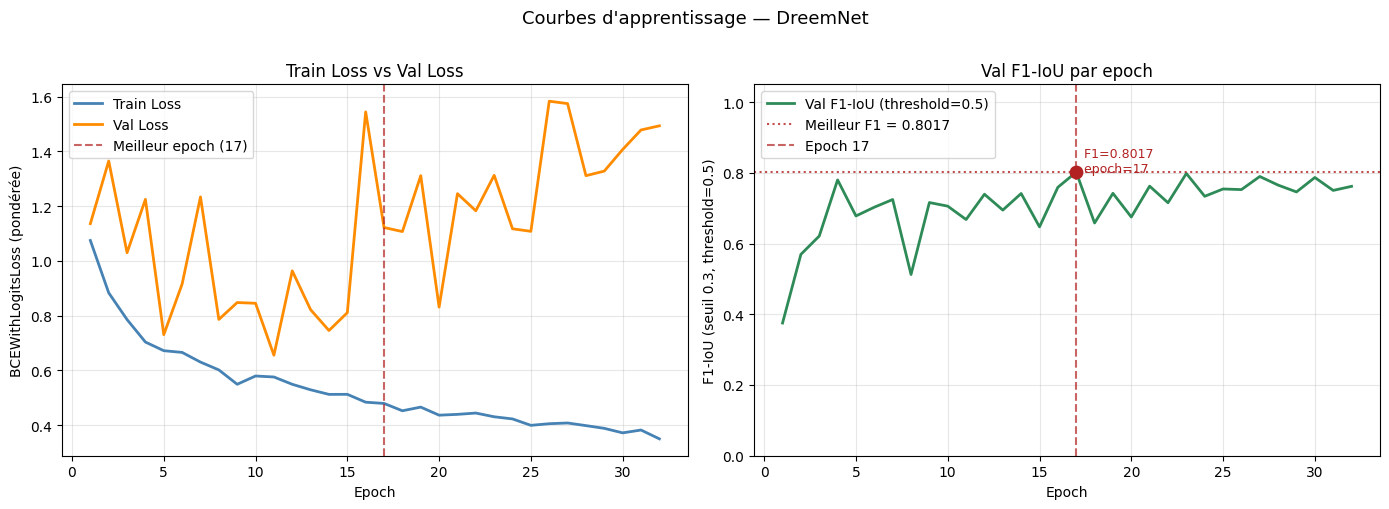

Figure sauvegardée : /kaggle/working/figures/learning_curves.png

Note : Val F1 calculé avec threshold=0.5 (non calibré).
       La section 10 calibre le seuil optimal — le F1 réel peut être supérieur.


In [18]:
# ── Courbes d'apprentissage ────────────────────────────────────────────────────
epochs_range = np.arange(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'apprentissage — DreemNet', fontsize=13, y=1.01)

# ── Subplot 1 : Loss ──────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs_range, history['train_loss'], label='Train Loss',
         color='steelblue', linewidth=2)
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',
         color='darkorange', linewidth=2)
ax1.axvline(best_epoch, color='firebrick', linestyle='--', alpha=0.7,
            label=f'Meilleur epoch ({best_epoch})')
ax1.set_title('Train Loss vs Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss (pondérée)')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Subplot 2 : Val F1 ────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_range, history['val_f1'], color='seagreen', linewidth=2,
         label='Val F1-IoU (threshold=0.5)')
ax2.axhline(best_val_f1, color='firebrick', linestyle=':', alpha=0.8,
            label=f'Meilleur F1 = {best_val_f1:.4f}')
ax2.axvline(best_epoch, color='firebrick', linestyle='--', alpha=0.7,
            label=f'Epoch {best_epoch}')
# Annotation du point optimal
ax2.scatter([best_epoch], [best_val_f1], color='firebrick', zorder=5, s=80)
ax2.annotate(
    f'  F1={best_val_f1:.4f}\n  epoch={best_epoch}',
    xy=(best_epoch, best_val_f1),
    fontsize=9, color='firebrick'
)
ax2.set_title('Val F1-IoU par epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1-IoU (seuil 0.3, threshold=0.5)')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
curve_path = FIGURES_DIR / 'learning_curves.png'
plt.savefig(curve_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {curve_path}")
print()
print("Note : Val F1 calculé avec threshold=0.5 (non calibré).")
print("       La section 10 calibre le seuil optimal — le F1 réel peut être supérieur.")

---

## Amélioration 1 — Post-processing : filtre médian sur les probabilités

### Justification clinique

La définition AASM 2012 de l'apnée obstructive exige une **durée minimale de 10 secondes**. La durée médiane des événements dans ce dataset est de **17 secondes** (EDA, notebook 01). Par conséquent :

- Une prédiction positive **isolée** (1 seconde entourée de 0) est quasi-certainement un **artefact** du modèle, non une vraie apnée.
- La métrique F1-IoU (seuil IoU ≥ 0.3) est doublement pénalisée par ces faux positifs isolés : ils augmentent FP *et* fragmentent les événements, réduisant l'IoU des TP adjacents.

Un **filtre médian** de taille `k` sur les probabilités brutes conserve les plateaux (événements ≥ k/2 secondes) et **supprime les pics isolés**, sans aucun réentraînement.

| Kernel | Durée minimale filtrée | Usage |
|---|---|---|
| k=3 | ~1.5 s | Conservateur |
| **k=5** | **~2.5 s** | **Recommandé** |
| k=7 | ~3.5 s | Agressif — risque de tronquer de courtes apnées |

Les trois tailles sont comparées par cross-validation sur le **val set uniquement** (pas de fuite vers le test).

## Amélioration 2 — Calibration du seuil après lissage médian

Le lissage médian modifie la distribution des probabilités : les plateaux montent, les pics s'aplatissent. Le threshold optimal **change après lissage** et doit être recalibré.

La procédure : balayage de `threshold ∈ [0.10, 0.90]` par pas de 0.05 sur la validation, **séparément pour chaque kernel size** et sans lissage. La courbe F1-IoU vs threshold est affichée avant et après lissage médian pour quantifier le gain net.

---

---

## 10. Calibration du seuil de décision

### Pourquoi calibrer le threshold ?

La sigmoïde transforme les logits en scores dans $[0, 1]$, mais ces scores **ne sont pas des probabilités calibrées**. Avec un `pos_weight` de 12.23, la loss encourage le modèle à placer les logits des positifs très haut et des négatifs très bas — mais le point de croisement $\sigma(x) = 0.5$ (i.e., $x = 0$) n'est pas nécessairement le seuil qui maximise le F1.

Intuition : avec un fort déséquilibre, le modèle peut générer beaucoup de prédictions positives avec des scores entre 0.2 et 0.5. Seuiller à 0.5 les classerait toutes comme négatifs — faisant exploser les FN. Un seuil à 0.3 ou 0.25 pourrait récupérer ces TP à un coût de FP acceptable.

> **Règle importante :** la calibration est effectuée sur la **validation uniquement** (jamais sur le test) pour éviter le data leakage.

---

In [19]:
# ── Chargement du meilleur modèle ──────────────────────────────────────────────
print(f"Chargement du meilleur modèle depuis {BEST_MODEL_PATH} ...")
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"  Epoch sauvegardée : {checkpoint['epoch']}")
print(f"  Val F1 (threshold=0.5) : {checkpoint['val_f1']:.4f}")

# ── Collecte des probabilités sur la validation ────────────────────────────────
print("\nInférence sur le val set pour calibration ...")
all_probs_val  = []
all_labels_val = []

with torch.no_grad():
    for x_batch, y_batch in loader_val:
        x_batch = x_batch.to(device, non_blocking=True)
        logits  = model(x_batch)
        probs   = torch.sigmoid(logits).cpu().numpy()
        all_probs_val.append(probs)
        all_labels_val.append(y_batch.numpy())

all_probs_val  = np.concatenate(all_probs_val,  axis=0)   # (1000, 90)
all_labels_val = np.concatenate(all_labels_val, axis=0)   # (1000, 90)
print(f"  Probs val collectées : {all_probs_val.shape}")

Chargement du meilleur modèle depuis /kaggle/working/best_model.pth ...
  Epoch sauvegardée : 17
  Val F1 (threshold=0.5) : 0.8017

Inférence sur le val set pour calibration ...
  Probs val collectées : (1000, 90)


In [20]:
# ── Balayage des thresholds SANS lissage ──────────────────────────────────────
thresholds  = np.arange(0.1, 0.95, 0.05)
f1_by_thr   = []

print(f"Balayage de {len(thresholds)} thresholds (sans lissage médian) ...")
for thr in tqdm(thresholds, desc='Sans lissage'):
    f1 = compute_batch_f1(all_labels_val, all_probs_val, threshold=thr)
    f1_by_thr.append(f1)

f1_by_thr     = np.array(f1_by_thr)
best_thr_idx  = np.argmax(f1_by_thr)
best_threshold = float(thresholds[best_thr_idx])
best_f1_calib = float(f1_by_thr[best_thr_idx])
print(f"  Threshold optimal (brut) : {best_threshold:.2f}  |  F1={best_f1_calib:.4f}")

# ── Balayage avec lissage médian (kernel 3, 5, 7) ─────────────────────────────
print(f"\nBalayage avec lissage médian (kernels = {MEDIAN_KERNEL_SIZES}) ...")
median_results = {}

for kernel in MEDIAN_KERNEL_SIZES:
    # Lissage médian le long de l'axe temporel (axis=-1), indépendant par sample
    probs_smooth = median_filter(all_probs_val, size=(1, kernel))
    f1_smooth    = []
    for thr in tqdm(thresholds, desc=f'  kernel={kernel}', leave=False):
        f1_smooth.append(compute_batch_f1(all_labels_val, probs_smooth, threshold=thr))
    f1_smooth = np.array(f1_smooth)
    best_idx  = np.argmax(f1_smooth)
    median_results[kernel] = {
        'probs_smooth' : probs_smooth,
        'f1_by_thr'   : f1_smooth,
        'best_threshold': float(thresholds[best_idx]),
        'best_f1'     : float(f1_smooth[best_idx])
    }
    print(f"  kernel={kernel}: threshold={float(thresholds[best_idx]):.2f}  |  "
          f"F1={float(f1_smooth[best_idx]):.4f}  "
          f"(gain vs brut: {float(f1_smooth[best_idx]) - best_f1_calib:+.4f})")

# ── Sélection du meilleur kernel ──────────────────────────────────────────────
best_kernel     = max(median_results, key=lambda k: median_results[k]['best_f1'])
best_threshold_median = median_results[best_kernel]['best_threshold']
best_f1_median  = median_results[best_kernel]['best_f1']

print(f"\n{'='*55}")
print(f"MEILLEUR KERNEL  : {best_kernel}")
print(f"Threshold médian : {best_threshold_median:.2f}")
print(f"F1 médian        : {best_f1_median:.4f}")
print(f"Gain net         : {best_f1_median - best_f1_calib:+.4f}")
print(f"{'='*55}")

# Affichage tableau de comparaison complet
print(f"\n{'Threshold':>10} | {'F1 brut':>8} | {' | '.join(f'F1 k={k}' for k in MEDIAN_KERNEL_SIZES)}")
print("-" * (10 + 2 + 9 + 2 + len(MEDIAN_KERNEL_SIZES) * 10))
for j, thr in enumerate(thresholds):
    row = f"{thr:>10.2f} | {f1_by_thr[j]:>8.4f}"
    for k in MEDIAN_KERNEL_SIZES:
        row += f" | {median_results[k]['f1_by_thr'][j]:>8.4f}"
    marks = []
    if abs(thr - best_threshold) < 1e-9:
        marks.append("← brut optimal")
    if abs(thr - best_threshold_median) < 1e-9:
        marks.append(f"← k={best_kernel} optimal")
    row += "  " + ", ".join(marks) if marks else ""
    print(row)


Balayage de 17 thresholds (sans lissage médian) ...


Sans lissage:   0%|          | 0/17 [00:00<?, ?it/s]

  Threshold optimal (brut) : 0.90  |  F1=0.8620

Balayage avec lissage médian (kernels = [3, 5, 7]) ...


  kernel=3:   0%|          | 0/17 [00:00<?, ?it/s]

  kernel=3: threshold=0.90  |  F1=0.8634  (gain vs brut: +0.0013)


  kernel=5:   0%|          | 0/17 [00:00<?, ?it/s]

  kernel=5: threshold=0.90  |  F1=0.8635  (gain vs brut: +0.0015)


  kernel=7:   0%|          | 0/17 [00:00<?, ?it/s]

  kernel=7: threshold=0.90  |  F1=0.8645  (gain vs brut: +0.0025)

MEILLEUR KERNEL  : 7
Threshold médian : 0.90
F1 médian        : 0.8645
Gain net         : +0.0025

 Threshold |  F1 brut | F1 k=3 | F1 k=5 | F1 k=7
-----------------------------------------------------
      0.10 |   0.2669 |   0.2702 |   0.4205 |   0.4226
      0.15 |   0.5004 |   0.5040 |   0.5827 |   0.5889
      0.20 |   0.6254 |   0.6288 |   0.6740 |   0.6757
      0.25 |   0.6936 |   0.6975 |   0.7211 |   0.7208
      0.30 |   0.7294 |   0.7357 |   0.7472 |   0.7514
      0.35 |   0.7536 |   0.7580 |   0.7695 |   0.7709
      0.40 |   0.7758 |   0.7788 |   0.7865 |   0.7928
      0.45 |   0.7914 |   0.7953 |   0.7987 |   0.8007
      0.50 |   0.8017 |   0.8038 |   0.8073 |   0.8093
      0.55 |   0.8122 |   0.8146 |   0.8217 |   0.8224
      0.60 |   0.8239 |   0.8293 |   0.8321 |   0.8345
      0.65 |   0.8319 |   0.8377 |   0.8390 |   0.8400
      0.70 |   0.8409 |   0.8421 |   0.8433 |   0.8454
      0.75 |   0

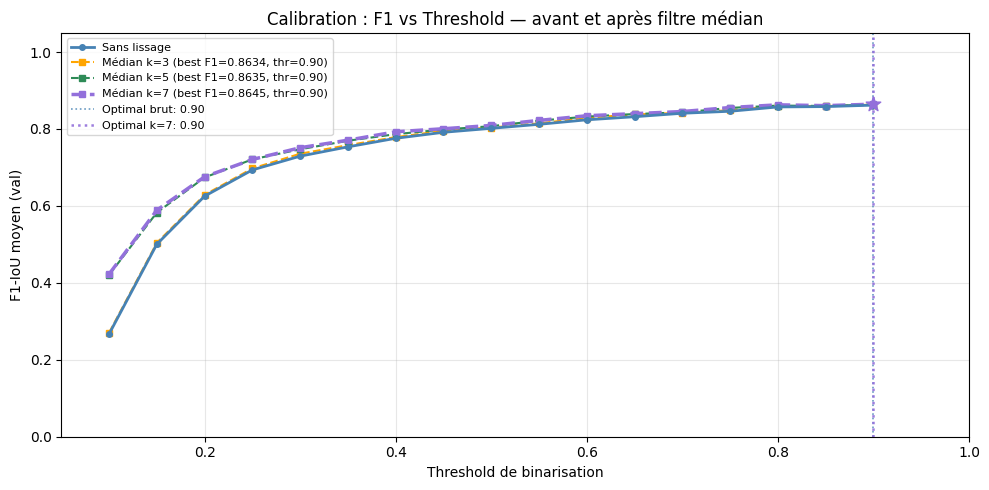

Figure sauvegardée : /kaggle/working/figures/threshold_calibration_v2.png
Checkpoint mis à jour : threshold=0.90, threshold_median=0.90 (k=7)


In [21]:
# ── Courbe F1 vs Threshold — avant et après lissage médian ────────────────────
colors_median = {3: 'orange', 5: 'seagreen', 7: 'mediumpurple'}

fig, ax = plt.subplots(figsize=(10, 5))

# Courbe sans lissage
ax.plot(thresholds, f1_by_thr, color='steelblue', linewidth=2,
        marker='o', markersize=4, label='Sans lissage', zorder=3)

# Courbes avec lissage médian
for k in MEDIAN_KERNEL_SIZES:
    r = median_results[k]
    lw = 2.5 if k == best_kernel else 1.5
    ax.plot(thresholds, r['f1_by_thr'],
            color=colors_median[k], linewidth=lw, linestyle='--',
            marker='s', markersize=4,
            label=f'Médian k={k} (best F1={r["best_f1"]:.4f}, thr={r["best_threshold"]:.2f})')

# Marqueurs optimaux
ax.axvline(best_threshold, color='steelblue', linestyle=':', linewidth=1.2,
           alpha=0.8, label=f'Optimal brut: {best_threshold:.2f}')
ax.axvline(best_threshold_median, color=colors_median[best_kernel],
           linestyle=':', linewidth=1.8, alpha=0.9,
           label=f'Optimal k={best_kernel}: {best_threshold_median:.2f}')
ax.scatter([best_threshold_median], [best_f1_median],
           color=colors_median[best_kernel], zorder=5, s=120, marker='*')

ax.set_xlabel('Threshold de binarisation')
ax.set_ylabel('F1-IoU moyen (val)')
ax.set_title('Calibration : F1 vs Threshold — avant et après filtre médian')
ax.set_xlim(0.05, 1.0)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
calib_path = FIGURES_DIR / 'threshold_calibration_v2.png'
plt.savefig(calib_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {calib_path}")

# ── Mise à jour des métadonnées du checkpoint ──────────────────────────────────
checkpoint['threshold']          = best_threshold
checkpoint['threshold_median']   = best_threshold_median
checkpoint['best_kernel']        = best_kernel
checkpoint['val_f1_calibrated']  = best_f1_calib
checkpoint['val_f1_median']      = best_f1_median
torch.save(checkpoint, BEST_MODEL_PATH)
print(f"Checkpoint mis à jour : threshold={best_threshold:.2f}, "
      f"threshold_median={best_threshold_median:.2f} (k={best_kernel})")


---

## 11. Évaluation finale sur la validation

### Analyse visuelle des prédictions

On visualise 4 exemples en sélectionnant, dans la mesure du possible, 2 fenêtres provenant de sujets au taux d'apnée élevé (depuis le train, pour illustration) et 2 depuis la validation. La visualisation montre :

- **Vert (TP)** : secondes correctement prédites comme apnée
- **Rouge (FP)** : secondes prédites apnée mais normales en réalité
- **Bleu (FN)** : secondes d'apnée manquées par le modèle

Les canaux AirFlow et SpO₂ sont les plus discriminants cliniquement : l'AirFlow tombe à zéro pendant l'apnée, et la SpO₂ chute avec un délai de 15-20 s.

### Honnêteté sur le biais de validation

Le F1 calculé ici est sur les 5 sujets de validation (taux d'apnée moyen ~4.5%), soit des cas nettement plus légers que la moyenne du jeu d'entraînement (~7.6%). Un F1 élevé en validation n'implique pas nécessairement de bonnes performances sur les sujets sévères du test set (sujets 22-43, inconnus). La cross-validation GroupKFold (section 13) est la solution robuste.

---

In [22]:
# ── F1 final sur la validation avec best_threshold ────────────────────────────
final_f1 = compute_batch_f1(all_labels_val, all_probs_val, threshold=best_threshold)
print(f"F1-IoU final sur val (threshold={best_threshold:.2f}) : {final_f1:.4f}")
print(f"(Rappel : val biaisée — sujets {{0, 1, 8, 13, 15}}, taux apnée moyen ~4.5%)")

F1-IoU final sur val (threshold=0.90) : 0.8620
(Rappel : val biaisée — sujets {0, 1, 8, 13, 15}, taux apnée moyen ~4.5%)


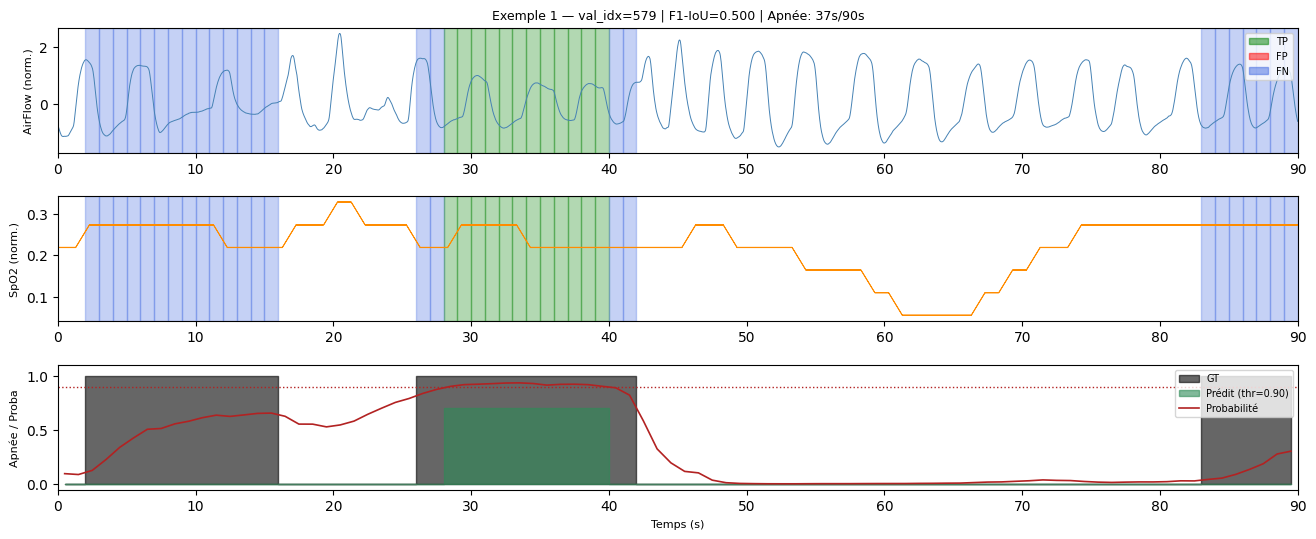

  Sauvegardé : /kaggle/working/figures/eval_example_1.png


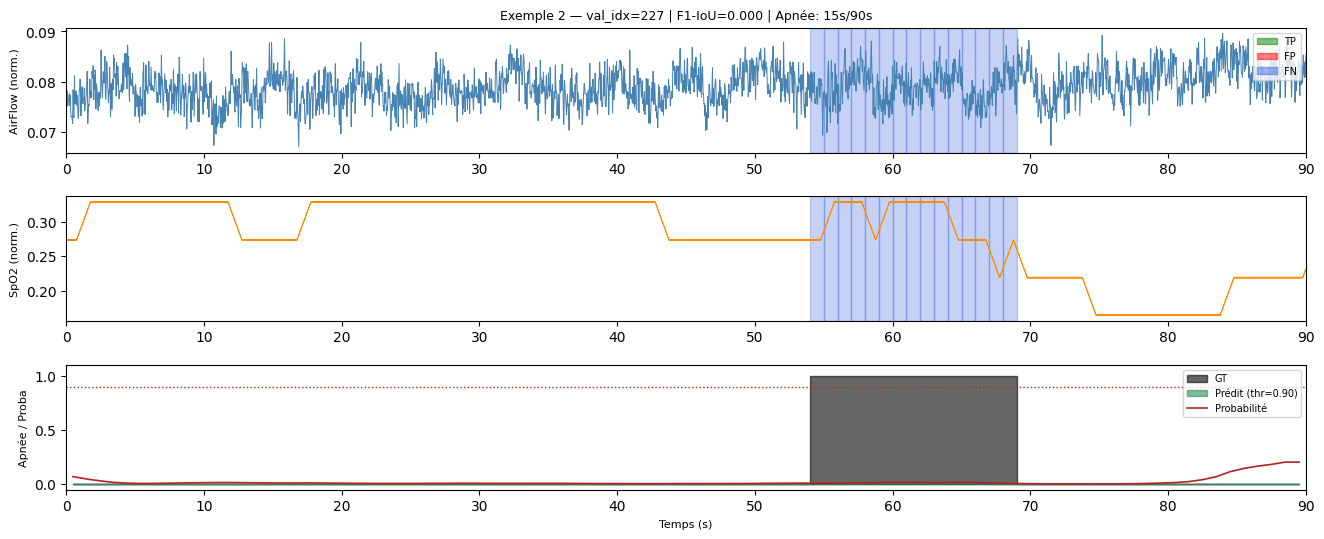

  Sauvegardé : /kaggle/working/figures/eval_example_2.png


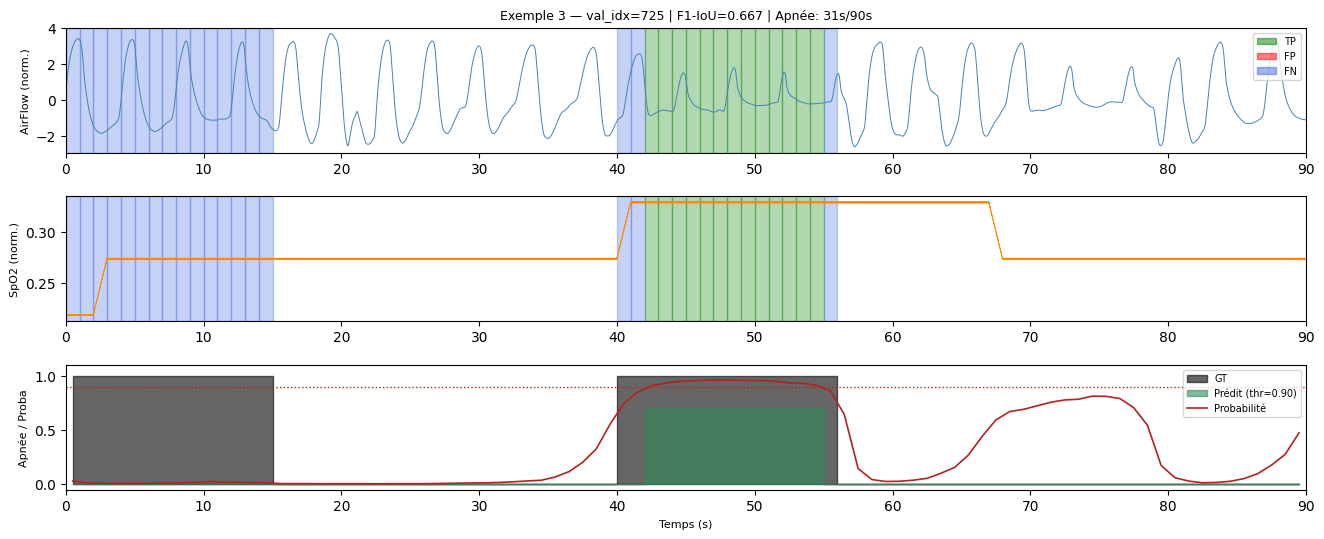

  Sauvegardé : /kaggle/working/figures/eval_example_3.png


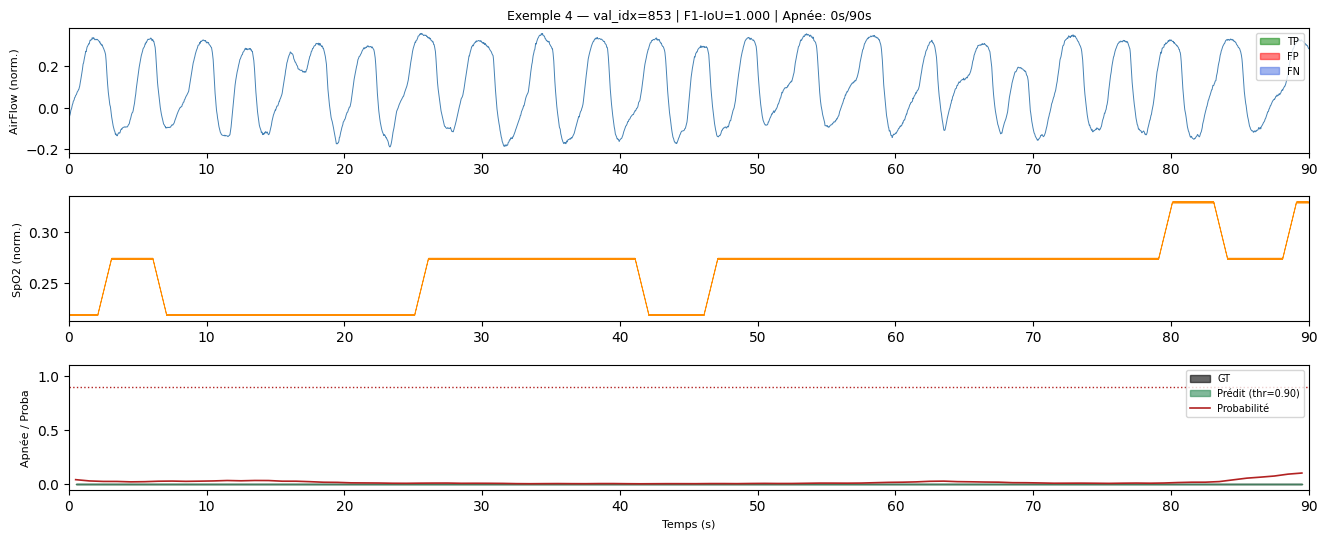

  Sauvegardé : /kaggle/working/figures/eval_example_4.png


In [23]:
# ── Visualisation de 4 exemples val ───────────────────────────────────────────
# Indices des canaux les plus discriminants
AIRFLOW_IDX = SIGNAL_NAMES.index('AirFlow')   # 1
SPO2_IDX    = SIGNAL_NAMES.index('SpO2')       # 5

# Sélectionner 4 exemples val : préférer les fenêtres avec apnées
y_val_any = y_val.sum(axis=1)    # nombre de secondes en apnée par fenêtre
positive_indices = np.where(y_val_any > 0)[0]
negative_indices = np.where(y_val_any == 0)[0]

rng = np.random.default_rng(RANDOM_SEED)
n_pos = min(3, len(positive_indices))
n_neg = 4 - n_pos
chosen = np.concatenate([
    rng.choice(positive_indices, size=n_pos, replace=False),
    rng.choice(negative_indices, size=n_neg, replace=False) if n_neg > 0 else []
])
chosen = chosen[:4].astype(int)

time_sig = np.arange(N_SAMPLES_PER_SIGNAL) / SIGNAL_FREQ
time_lbl = np.arange(N_LABEL_COLS)

for ex_no, val_idx_local in enumerate(chosen):
    y_true_ex  = all_labels_val[val_idx_local]                     # (90,)
    y_prob_ex  = all_probs_val[val_idx_local]                      # (90,)
    y_pred_ex  = (y_prob_ex >= best_threshold).astype(int)         # (90,)

    # TP / FP / FN
    tp_mask = (y_true_ex == 1) & (y_pred_ex == 1)
    fp_mask = (y_true_ex == 0) & (y_pred_ex == 1)
    fn_mask = (y_true_ex == 1) & (y_pred_ex == 0)

    f1_ex = compute_f1_iou(y_true_ex, y_pred_ex)

    fig, axes = plt.subplots(3, 1, figsize=(16, 6), sharex=False,
                              gridspec_kw={'hspace': 0.35})

    # Signal AirFlow
    ax_air = axes[0]
    ax_air.plot(time_sig, X_val[val_idx_local][AIRFLOW_IDX], color='steelblue',
                linewidth=0.7)
    ax_air.set_ylabel('AirFlow (norm.)', fontsize=8)
    ax_air.set_xlim(0, WINDOW_SECS)
    for s in range(N_LABEL_COLS):
        if tp_mask[s]: ax_air.axvspan(s, s+1, color='green',   alpha=0.3)
        if fp_mask[s]: ax_air.axvspan(s, s+1, color='red',     alpha=0.3)
        if fn_mask[s]: ax_air.axvspan(s, s+1, color='royalblue', alpha=0.3)
    ax_air.set_title(f'Exemple {ex_no+1} — val_idx={val_idx_local} | '
                     f'F1-IoU={f1_ex:.3f} | '
                     f'Apnée: {int(y_true_ex.sum())}s/{N_LABEL_COLS}s',
                     fontsize=9)

    # Signal SpO2
    ax_spo = axes[1]
    ax_spo.plot(time_sig, X_val[val_idx_local][SPO2_IDX], color='darkorange',
                linewidth=0.7)
    ax_spo.set_ylabel('SpO2 (norm.)', fontsize=8)
    ax_spo.set_xlim(0, WINDOW_SECS)
    for s in range(N_LABEL_COLS):
        if tp_mask[s]: ax_spo.axvspan(s, s+1, color='green',   alpha=0.3)
        if fp_mask[s]: ax_spo.axvspan(s, s+1, color='red',     alpha=0.3)
        if fn_mask[s]: ax_spo.axvspan(s, s+1, color='royalblue', alpha=0.3)

    # Masques GT vs Prédiction
    ax_msk = axes[2]
    ax_msk.fill_between(time_lbl + 0.5, 0, y_true_ex, step='mid',
                        color='black', alpha=0.6, label='GT')
    ax_msk.fill_between(time_lbl + 0.5, 0, y_pred_ex * 0.7, step='mid',
                        color='seagreen', alpha=0.6, label=f'Prédit (thr={best_threshold:.2f})')
    ax_msk.plot(time_lbl + 0.5, y_prob_ex, color='firebrick', linewidth=1.2,
                label='Probabilité')
    ax_msk.axhline(best_threshold, color='firebrick', linestyle=':', linewidth=1)
    ax_msk.set_ylabel('Apnée / Proba', fontsize=8)
    ax_msk.set_xlabel('Temps (s)', fontsize=8)
    ax_msk.set_xlim(0, WINDOW_SECS)
    ax_msk.set_ylim(-0.05, 1.1)
    ax_msk.legend(fontsize=7, loc='upper right')

    # Légende TP/FP/FN
    patches = [
        mpatches.Patch(color='green',     alpha=0.5, label='TP'),
        mpatches.Patch(color='red',       alpha=0.5, label='FP'),
        mpatches.Patch(color='royalblue', alpha=0.5, label='FN'),
    ]
    axes[0].legend(handles=patches, fontsize=7, loc='upper right')

    plt.tight_layout()
    fig_path = FIGURES_DIR / f'eval_example_{ex_no+1}.png'
    plt.savefig(fig_path, dpi=90, bbox_inches='tight')
    plt.show()
    print(f"  Sauvegardé : {fig_path}")

---

## 12. Génération de la soumission

### Format requis

La soumission doit respecter le format du challenge : un fichier CSV avec :
- Colonne `id` : identifiant de la fenêtre (colonne 0 de `X_test.h5`)
- Colonnes `y_0` à `y_89` : prédiction binaire pour chaque seconde

### Sanity check

On compare le pourcentage d'apnées prédit sur le test au pourcentage observé dans le train (7.6%). Une valeur très éloignée (p. ex. < 1% ou > 20%) indiquerait un problème de seuillage ou de normalisation. Cette vérification ne garantit pas la qualité des prédictions mais détecte les erreurs grossières.

---

In [24]:
# ── Inférence sur X_test — avec filtre médian (Amélioration 1) ───────────────
print(f"Inférence sur X_test ({len(ds_test)} fenêtres) ...")
print(f"  Filtre médian  : kernel={best_kernel}")
print(f"  Threshold      : {best_threshold_median:.2f}  (calibré sur val après lissage)")

model.eval()
all_probs_test_raw = []

with torch.no_grad():
    for x_batch in tqdm(loader_test, desc='Test inference v1'):
        x_batch = x_batch.to(device, non_blocking=True)
        logits  = model(x_batch)
        probs   = torch.sigmoid(logits).cpu().numpy()          # (batch, 90)
        all_probs_test_raw.append(probs)

all_probs_test_raw = np.concatenate(all_probs_test_raw, axis=0)   # (4400, 90)

# ── Lissage médian AVANT binarisation ─────────────────────────────────────────
# size=(1, kernel) : filtre le long de l'axe temps, indépendant par sample
all_probs_test_smooth = median_filter(all_probs_test_raw, size=(1, best_kernel))

# ── Binarisation avec threshold calibré après lissage ─────────────────────────
all_preds_test = (all_probs_test_smooth >= best_threshold_median).astype(np.int8)

print(f"\nPrédictions test : {all_preds_test.shape}  dtype={all_preds_test.dtype}")
print(f"  % apnées (raw)     : {all_probs_test_raw.mean()*100:.2f}%")
print(f"  % apnées (smooth)  : {all_probs_test_smooth.mean()*100:.2f}%")
print(f"  % apnées (binaire) : {all_preds_test.mean()*100:.2f}%")


Inférence sur X_test (4400 fenêtres) ...
  Filtre médian  : kernel=7
  Threshold      : 0.90  (calibré sur val après lissage)


Test inference v1:   0%|          | 0/69 [00:00<?, ?it/s]


Prédictions test : (4400, 90)  dtype=int8
  % apnées (raw)     : 11.62%
  % apnées (smooth)  : 11.55%
  % apnées (binaire) : 2.74%


In [25]:
# ── Construction du DataFrame de soumission ────────────────────────────────────
label_cols = [f'y_{i}' for i in range(N_LABEL_COLS)]
df_submit  = pd.DataFrame(all_preds_test, columns=label_cols)
df_submit.insert(0, 'id', test_ids)

# ── Sauvegarde ─────────────────────────────────────────────────────────────────
submit_path = OUTPUT_DIR / 'submission_v1.csv'  # DreemNet v1 + médian k={best_kernel} + thr={best_threshold_median:.2f}
df_submit.to_csv(submit_path, index=False)

print(f"Soumission sauvegardée : {submit_path}")
print(f"Shape : {df_submit.shape}")
print(f"\nPremières lignes :")
print(df_submit.iloc[:3, :8].to_string())
print("...")

Soumission sauvegardée : /kaggle/working/submission_v1.csv
Shape : (4400, 91)

Premières lignes :
     id  y_0  y_1  y_2  y_3  y_4  y_5  y_6
0  4400    0    0    0    0    0    0    0
1  4401    0    0    0    0    0    0    0
2  4402    0    0    0    0    0    0    0
...


Sanity check — Distribution des prédictions :
  % apnées dans y_train (ref)      : 7.56%
  % apnées dans y_val              : 4.54%
  % apnées prédites sur test       : 2.74%
  Ratio test/train                 : 0.36
  ⚠ Sous-prédiction importante — envisager de baisser le threshold

  Fenêtres avec ≥1 s d'apnée prédite : 11.7%
  (Référence train : 20.5% des fenêtres positives)


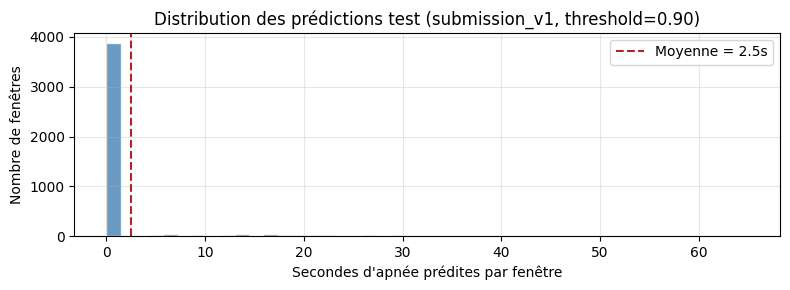

Figure sauvegardée : /kaggle/working/figures/submission_distribution.png


In [26]:
# ── Sanity check : distribution des prédictions ────────────────────────────────
pct_apnea_test  = all_preds_test.mean() * 100
pct_apnea_train = y_train.mean() * 100
pct_apnea_val   = y_val.mean() * 100

print("Sanity check — Distribution des prédictions :")
print(f"  % apnées dans y_train (ref)      : {pct_apnea_train:.2f}%")
print(f"  % apnées dans y_val              : {pct_apnea_val:.2f}%")
print(f"  % apnées prédites sur test       : {pct_apnea_test:.2f}%")

ratio = pct_apnea_test / pct_apnea_train
print(f"  Ratio test/train                 : {ratio:.2f}")

if 0.5 <= ratio <= 2.5:
    print("  → Cohérent avec la distribution train ✓")
elif ratio < 0.5:
    print("  ⚠ Sous-prédiction importante — envisager de baisser le threshold")
else:
    print("  ⚠ Sur-prédiction importante — envisager de monter le threshold")

# ── Distribution par fenêtre ───────────────────────────────────────────────────
apnea_per_window = all_preds_test.sum(axis=1)   # secondes d'apnée par fenêtre
pct_positive_windows = (apnea_per_window > 0).mean() * 100
print(f"\n  Fenêtres avec ≥1 s d'apnée prédite : {pct_positive_windows:.1f}%")
print(f"  (Référence train : 20.5% des fenêtres positives)")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(apnea_per_window, bins=45, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Secondes d\'apnée prédites par fenêtre')
ax.set_ylabel('Nombre de fenêtres')
ax.set_title(f'Distribution des prédictions test (submission_v1, threshold={best_threshold:.2f})')
ax.axvline(apnea_per_window.mean(), color='firebrick', linestyle='--',
           label=f'Moyenne = {apnea_per_window.mean():.1f}s')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
dist_path = FIGURES_DIR / 'submission_distribution.png'
plt.savefig(dist_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {dist_path}")

---

## 14. Amélioration 5 — Entraînement DreemNetV2

### Récapitulatif des améliorations combinées

| Amélioration | Description | Implémentée dans |
|---|---|---|
| **Augmentation** | Bruit + time shift + channel dropout | `DreemDataset(augment=True)` |
| **Architecture** | CNN + Transformer (2 couches, 8 têtes) | `DreemNetV2` |
| **Post-processing** | Filtre médian k=best_kernel + threshold calibré | Inférence |
| **Entraînement long** | 60 epochs, patience=15 (vs 50/10 pour v1) | Training loop v2 |

DreemNetV2 est entraîné à partir de zéro avec le même optimiseur, la même loss et les mêmes DataLoaders que v1 (incluant l'augmentation déjà activée sur `ds_train`). Le meilleur modèle est sauvegardé dans `best_model_v2.pth`.

---

In [27]:
# ── Instanciation DreemNetV2 ──────────────────────────────────────────────────
model_v2 = DreemNetV2(
    n_channels=N_SIGNALS,
    cnn_channels=[32, 64, 128],
    d_model=128,
    nhead=8,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.1
).to(device)

n_params = sum(p.numel() for p in model_v2.parameters() if p.requires_grad)
print(f"DreemNetV2 instancié sur {device}")
print(f"  Paramètres entraînables : {n_params:,}")

# Vérification forward pass
with torch.no_grad():
    _x = torch.zeros(2, N_SIGNALS, 9000).to(device)
    _out = model_v2(_x)
    assert _out.shape == (2, 90), f"Shape inattendue : {_out.shape}"
    print(f"  Forward pass OK : {_out.shape}  ✓")
del _x, _out

DreemNetV2 instancié sur cuda
  Paramètres entraînables : 327,745
  Forward pass OK : torch.Size([2, 90])  ✓


In [28]:
# ── Loss, optimiseur, scheduler et early stopping pour DreemNetV2 ─────────────
BEST_MODEL_V2_PATH = OUTPUT_DIR / 'best_model_v2.pth'

criterion_v2 = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([POS_WEIGHT]).to(device)
)
optimizer_v2 = torch.optim.Adam(
    model_v2.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler_v2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_v2, T_max=MAX_EPOCHS, eta_min=1e-5
)
early_stopping_v2 = EarlyStopping(patience=PATIENCE, mode='max')

print(f"Configuration entraînement DreemNetV2 :")
print(f"  Loss        : BCEWithLogitsLoss(pos_weight={POS_WEIGHT})")
print(f"  Optimizer   : Adam(lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"  Scheduler   : CosineAnnealing(T_max={MAX_EPOCHS})")
print(f"  Epochs max  : {MAX_EPOCHS}  |  Patience : {PATIENCE}")
print(f"  Augmentation: activée (ds_train.augment={ds_train.augment})")

Configuration entraînement DreemNetV2 :
  Loss        : BCEWithLogitsLoss(pos_weight=12.23)
  Optimizer   : Adam(lr=0.001, wd=0.0001)
  Scheduler   : CosineAnnealing(T_max=60)
  Epochs max  : 60  |  Patience : 15
  Augmentation: activée (ds_train.augment=True)


In [29]:
# ── Boucle d'entraînement DreemNetV2 ─────────────────────────────────────────
history_v2 = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'lr': []}
best_val_f1_v2 = -np.inf
best_epoch_v2  = 0

print(f"Début de l'entraînement DreemNetV2 — {MAX_EPOCHS} epochs max")
print("=" * 75)

for epoch in range(1, MAX_EPOCHS + 1):
    current_lr = optimizer_v2.param_groups[0]['lr']

    train_loss_v2 = train_epoch(model_v2, loader_train, optimizer_v2,
                                criterion_v2, device)
    val_loss_v2, val_f1_v2 = evaluate(model_v2, loader_val, criterion_v2,
                                       device, threshold=0.5)
    scheduler_v2.step()

    history_v2['train_loss'].append(train_loss_v2)
    history_v2['val_loss'].append(val_loss_v2)
    history_v2['val_f1'].append(val_f1_v2)
    history_v2['lr'].append(current_lr)

    if val_f1_v2 > best_val_f1_v2:
        best_val_f1_v2 = val_f1_v2
        best_epoch_v2  = epoch
        torch.save({
            'epoch'      : epoch,
            'model_state': model_v2.state_dict(),
            'val_f1'     : val_f1_v2,
            'threshold'  : 0.5,
            'optimizer'  : optimizer_v2.state_dict()
        }, BEST_MODEL_V2_PATH)
        marker = ' ← meilleur'
    else:
        marker = ''

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss_v2:.4f} | "
        f"Val Loss: {val_loss_v2:.4f} | "
        f"Val F1: {val_f1_v2:.4f} | "
        f"LR: {current_lr:.2e}" + marker
    )

    if early_stopping_v2.step(val_f1_v2):
        print(f"\nEarly stopping epoch {epoch} "
              f"(pas d'amélioration depuis {PATIENCE} epochs).")
        break

print("=" * 75)
print(f"DreemNetV2 — Meilleur Val F1 : {best_val_f1_v2:.4f} (epoch {best_epoch_v2})")
print(f"Modèle sauvegardé : {BEST_MODEL_V2_PATH}")

Début de l'entraînement DreemNetV2 — 60 epochs max
Epoch 01/60 | Train Loss: 0.9689 | Val Loss: 1.2235 | Val F1: 0.6574 | LR: 1.00e-03 ← meilleur
Epoch 02/60 | Train Loss: 0.8317 | Val Loss: 0.9934 | Val F1: 0.5021 | LR: 9.99e-04
Epoch 03/60 | Train Loss: 0.7642 | Val Loss: 1.1822 | Val F1: 0.6959 | LR: 9.97e-04 ← meilleur
Epoch 04/60 | Train Loss: 0.7123 | Val Loss: 0.9214 | Val F1: 0.6272 | LR: 9.94e-04
Epoch 05/60 | Train Loss: 0.6835 | Val Loss: 0.9059 | Val F1: 0.5097 | LR: 9.89e-04
Epoch 06/60 | Train Loss: 0.6442 | Val Loss: 0.9034 | Val F1: 0.5335 | LR: 9.83e-04
Epoch 07/60 | Train Loss: 0.6567 | Val Loss: 1.0323 | Val F1: 0.5758 | LR: 9.76e-04
Epoch 08/60 | Train Loss: 0.6001 | Val Loss: 1.2608 | Val F1: 0.6721 | LR: 9.67e-04
Epoch 09/60 | Train Loss: 0.5859 | Val Loss: 1.1976 | Val F1: 0.6215 | LR: 9.57e-04
Epoch 10/60 | Train Loss: 0.5794 | Val Loss: 1.3689 | Val F1: 0.6114 | LR: 9.46e-04
Epoch 11/60 | Train Loss: 0.5753 | Val Loss: 1.3891 | Val F1: 0.5256 | LR: 9.34e-04
Epo

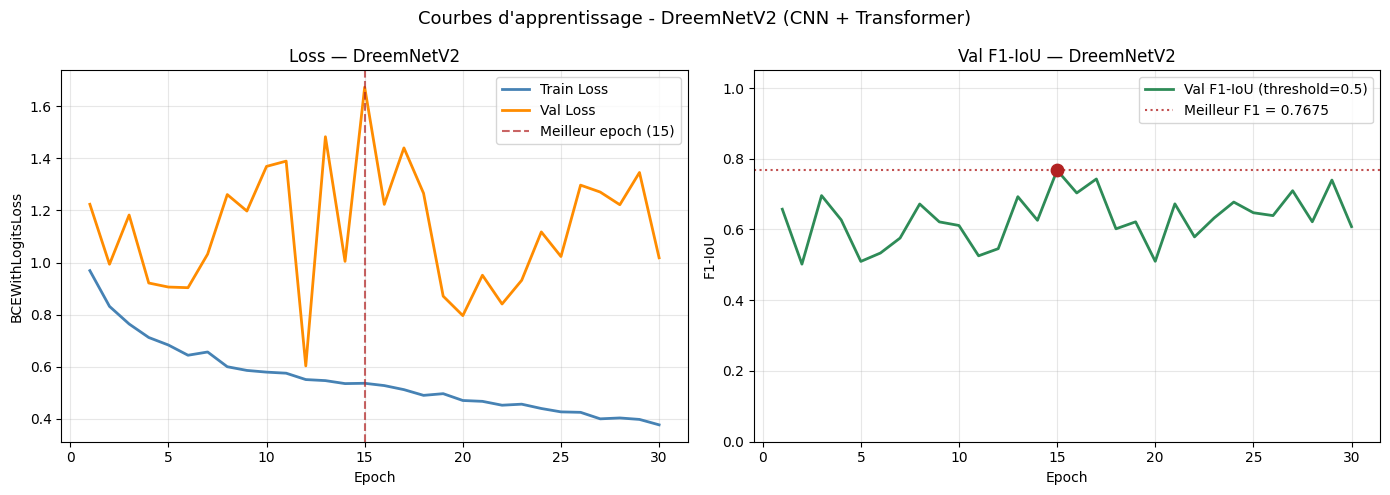

Figure sauvegardée : /kaggle/working/figures/learning_curves_v2.png


In [31]:
# ── Courbes d'apprentissage DreemNetV2 ────────────────────────────────────────
epochs_v2 = np.arange(1, len(history_v2['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes d'apprentissage - DreemNetV2 (CNN + Transformer)", fontsize=13)

ax1 = axes[0]
ax1.plot(epochs_v2, history_v2['train_loss'], label='Train Loss', color='steelblue', lw=2)
ax1.plot(epochs_v2, history_v2['val_loss'],   label='Val Loss',   color='darkorange', lw=2)
ax1.axvline(best_epoch_v2, color='firebrick', linestyle='--', alpha=0.7,
            label=f'Meilleur epoch ({best_epoch_v2})')
ax1.set_title('Loss — DreemNetV2')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(epochs_v2, history_v2['val_f1'], color='seagreen', lw=2,
         label='Val F1-IoU (threshold=0.5)')
ax2.axhline(best_val_f1_v2, color='firebrick', linestyle=':', alpha=0.8,
            label=f'Meilleur F1 = {best_val_f1_v2:.4f}')
ax2.scatter([best_epoch_v2], [best_val_f1_v2], color='firebrick', zorder=5, s=80)
ax2.set_title('Val F1-IoU — DreemNetV2')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1-IoU')
ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
curves_v2_path = FIGURES_DIR / 'learning_curves_v2.png'
plt.savefig(curves_v2_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {curves_v2_path}")

Chargement DreemNetV2 depuis /kaggle/working/best_model_v2.pth ...
  Epoch : 15  |  Val F1 : 0.7675
Calibration DreemNetV2 avec filtre médian ...
  kernel=3: threshold=0.90  |  F1=0.8494
  kernel=5: threshold=0.90  |  F1=0.8521
  kernel=7: threshold=0.90  |  F1=0.8541

Meilleur kernel DreemNetV2 : k=7, threshold=0.90, F1=0.8541


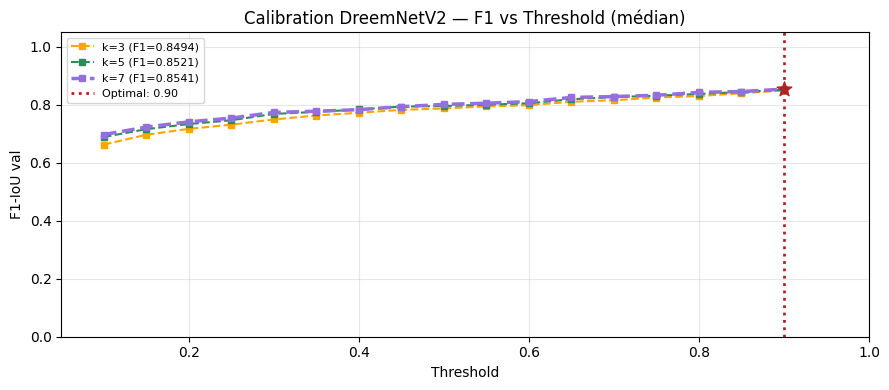

Figure sauvegardée : /kaggle/working/figures/threshold_calibration_v2_model.png


In [32]:
# ── Calibration du seuil pour DreemNetV2 (avec filtre médian) ─────────────────
print(f"Chargement DreemNetV2 depuis {BEST_MODEL_V2_PATH} ...")
ckpt_v2 = torch.load(BEST_MODEL_V2_PATH, map_location=device)
model_v2.load_state_dict(ckpt_v2['model_state'])
model_v2.eval()
print(f"  Epoch : {ckpt_v2['epoch']}  |  Val F1 : {ckpt_v2['val_f1']:.4f}")

# Collecte des probabilités val
all_probs_val_v2  = []
all_labels_val_v2 = []
with torch.no_grad():
    for x_batch, y_batch in loader_val:
        x_batch = x_batch.to(device, non_blocking=True)
        probs   = torch.sigmoid(model_v2(x_batch)).cpu().numpy()
        all_probs_val_v2.append(probs)
        all_labels_val_v2.append(y_batch.numpy())
all_probs_val_v2  = np.concatenate(all_probs_val_v2,  axis=0)
all_labels_val_v2 = np.concatenate(all_labels_val_v2, axis=0)

# Balayage thresholds + médian pour DreemNetV2
print("Calibration DreemNetV2 avec filtre médian ...")
median_results_v2 = {}
for kernel in MEDIAN_KERNEL_SIZES:
    probs_s = median_filter(all_probs_val_v2, size=(1, kernel))
    f1s = [compute_batch_f1(all_labels_val_v2, probs_s, threshold=t)
           for t in thresholds]
    f1s = np.array(f1s)
    best_idx = np.argmax(f1s)
    median_results_v2[kernel] = {
        'f1_by_thr'    : f1s,
        'best_threshold': float(thresholds[best_idx]),
        'best_f1'      : float(f1s[best_idx])
    }
    print(f"  kernel={kernel}: threshold={float(thresholds[best_idx]):.2f}  |  F1={float(f1s[best_idx]):.4f}")

best_kernel_v2 = max(median_results_v2, key=lambda k: median_results_v2[k]['best_f1'])
best_threshold_v2 = median_results_v2[best_kernel_v2]['best_threshold']
best_f1_v2 = median_results_v2[best_kernel_v2]['best_f1']
print(f"\nMeilleur kernel DreemNetV2 : k={best_kernel_v2}, threshold={best_threshold_v2:.2f}, F1={best_f1_v2:.4f}")

# Plot calibration v2
fig, ax = plt.subplots(figsize=(9, 4))
colors = {3: 'orange', 5: 'seagreen', 7: 'mediumpurple'}
for k in MEDIAN_KERNEL_SIZES:
    r = median_results_v2[k]
    ax.plot(thresholds, r['f1_by_thr'], color=colors[k],
            lw=2.5 if k == best_kernel_v2 else 1.5, linestyle='--',
            marker='s', markersize=4, label=f'k={k} (F1={r["best_f1"]:.4f})')
ax.axvline(best_threshold_v2, color='firebrick', linestyle=':', lw=2,
           label=f'Optimal: {best_threshold_v2:.2f}')
ax.scatter([best_threshold_v2], [best_f1_v2], color='firebrick', zorder=5, s=120, marker='*')
ax.set_title('Calibration DreemNetV2 — F1 vs Threshold (médian)')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1-IoU val')
ax.set_xlim(0.05, 1.0); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
calib_v2_path = FIGURES_DIR / 'threshold_calibration_v2_model.png'
plt.savefig(calib_v2_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {calib_v2_path}")

In [33]:
# ── Inférence test DreemNetV2 → submission_v2.csv ────────────────────────────
print(f"Inférence DreemNetV2 sur X_test ...")
print(f"  Filtre médian : k={best_kernel_v2}  |  Threshold : {best_threshold_v2:.2f}")

model_v2.eval()
all_probs_test_raw_v2 = []
with torch.no_grad():
    for x_batch in tqdm(loader_test, desc='Test inference v2'):
        x_batch = x_batch.to(device, non_blocking=True)
        probs   = torch.sigmoid(model_v2(x_batch)).cpu().numpy()
        all_probs_test_raw_v2.append(probs)

all_probs_test_raw_v2   = np.concatenate(all_probs_test_raw_v2, axis=0)
all_probs_test_smooth_v2 = median_filter(all_probs_test_raw_v2, size=(1, best_kernel_v2))
all_preds_test_v2       = (all_probs_test_smooth_v2 >= best_threshold_v2).astype(np.int8)

# ── Construction et sauvegarde submission_v2 ──────────────────────────────────
label_cols    = [f'y_{i}' for i in range(N_LABEL_COLS)]
df_submit_v2  = pd.DataFrame(all_preds_test_v2, columns=label_cols)
df_submit_v2.insert(0, 'id', test_ids)
submit_v2_path = OUTPUT_DIR / 'submission_v2.csv'
df_submit_v2.to_csv(submit_v2_path, index=False)
print(f"\nsubmission_v2.csv sauvegardé : {submit_v2_path}")
print(f"Shape : {df_submit_v2.shape}")

Inférence DreemNetV2 sur X_test ...
  Filtre médian : k=7  |  Threshold : 0.90


Test inference v2:   0%|          | 0/69 [00:00<?, ?it/s]


submission_v2.csv sauvegardé : /kaggle/working/submission_v2.csv
Shape : (4400, 91)


Métrique                            v1 (BiLSTM) v2 (Transf.)
------------------------------------------------------------
% apnées total                            2.74%        3.56%
Fenêtres avec ≥1 apnée (%)                11.7%        12.3%
Durée moyenne apnée/fenêtre (s)           2.46         3.21
Fenêtres 100% positives (%)                0.0%         0.0%
Fenêtres 100% négatives (%)               88.3%        87.7%


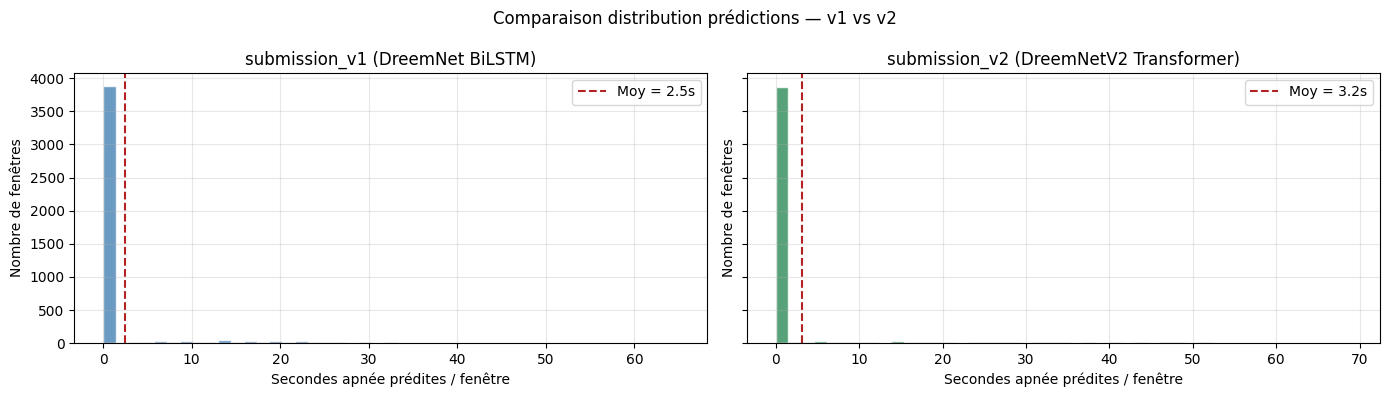

Figure sauvegardée : /kaggle/working/figures/submission_v1_vs_v2_comparison.png


In [34]:
# ── Comparaison côte à côte : submission_v1 vs submission_v2 ──────────────────
df_v1 = pd.read_csv(OUTPUT_DIR / 'submission_v1.csv')
df_v2 = pd.read_csv(OUTPUT_DIR / 'submission_v2.csv')

preds_v1 = df_v1[[f'y_{i}' for i in range(N_LABEL_COLS)]].values
preds_v2 = df_v2[[f'y_{i}' for i in range(N_LABEL_COLS)]].values

pct_v1 = preds_v1.mean() * 100
pct_v2 = preds_v2.mean() * 100

apnea_per_win_v1 = preds_v1.sum(axis=1)
apnea_per_win_v2 = preds_v2.sum(axis=1)

print("=" * 60)
print(f"{'Métrique':<35} {'v1 (BiLSTM)':>10} {'v2 (Transf.)':>12}")
print("-" * 60)
print(f"{'% apnées total':<35} {pct_v1:>10.2f}% {pct_v2:>11.2f}%")
print(f"{'Fenêtres avec ≥1 apnée (%)':<35} {(apnea_per_win_v1>0).mean()*100:>10.1f}% {(apnea_per_win_v2>0).mean()*100:>11.1f}%")
print(f"{'Durée moyenne apnée/fenêtre (s)':<35} {apnea_per_win_v1.mean():>10.2f} {apnea_per_win_v2.mean():>12.2f}")
print(f"{'Fenêtres 100% positives (%)':<35} {(apnea_per_win_v1==90).mean()*100:>10.1f}% {(apnea_per_win_v2==90).mean()*100:>11.1f}%")
print(f"{'Fenêtres 100% négatives (%)':<35} {(apnea_per_win_v1==0).mean()*100:>10.1f}% {(apnea_per_win_v2==0).mean()*100:>11.1f}%")
print("=" * 60)

# ── Histogrammes comparatifs ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle('Comparaison distribution prédictions — v1 vs v2', fontsize=12)

for ax, preds, label, color in zip(
    axes,
    [apnea_per_win_v1, apnea_per_win_v2],
    ['submission_v1 (DreemNet BiLSTM)', 'submission_v2 (DreemNetV2 Transformer)'],
    ['steelblue', 'seagreen']
):
    ax.hist(preds, bins=45, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(preds.mean(), color='firebrick', linestyle='--',
               label=f'Moy = {preds.mean():.1f}s')
    ax.set_xlabel('Secondes apnée prédites / fenêtre')
    ax.set_ylabel('Nombre de fenêtres')
    ax.set_title(label)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
comp_path = FIGURES_DIR / 'submission_v1_vs_v2_comparison.png'
plt.savefig(comp_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {comp_path}")

---

## 15. Amélioration 6 — Ensemble de modèles (DreemNet v1 + DreemNetV2)

### Théorie : réduction de variance par moyennage

L'ensemble repose sur le **théorème de décomposition biais-variance** : pour N modèles d'erreur ε² non corrélés, la variance de leur moyenne est ε²/N. En pratique, les corrélations réduisent ce gain, mais deux modèles d'**architectures différentes** (BiLSTM vs Transformer) font des erreurs complémentaires :

- **DreemNet v1 (BiLSTM)** : capture les transitions locales (début/fin d'apnée)
- **DreemNetV2 (Transformer)** : capture les structures globales (cycles récurrents, dépendances SpO₂ décalées)

L'ensemble moyennise les probabilités brutes avant lissage et binarisation :

$$p_{\text{ensemble}}(t) = \frac{p_{\text{v1}}(t) + p_{\text{v2}}(t)}{2}$$

Un filtre médian et une calibration de seuil sont ensuite appliqués sur la validation.

> *Référence : Zhou (2012). "Ensemble Methods: Foundations and Algorithms." CRC Press.*

---

In [35]:
# ── Chargement des deux modèles ───────────────────────────────────────────────
print("Chargement DreemNet v1 ...")
ckpt_v1_ens = torch.load(BEST_MODEL_PATH, map_location=device)
model_v1_ens = DreemNet(n_channels=N_SIGNALS).to(device)
model_v1_ens.load_state_dict(ckpt_v1_ens['model_state'])
model_v1_ens.eval()

print("Chargement DreemNetV2 ...")
ckpt_v2_ens = torch.load(BEST_MODEL_V2_PATH, map_location=device)
model_v2_ens = DreemNetV2(n_channels=N_SIGNALS).to(device)
model_v2_ens.load_state_dict(ckpt_v2_ens['model_state'])
model_v2_ens.eval()

# ── Calibration de l'ensemble sur la validation ───────────────────────────────
print("\nCollecte des probabilités d'ensemble sur la validation ...")
all_probs_ens_val = []
with torch.no_grad():
    for x_batch, y_batch in loader_val:
        x_batch = x_batch.to(device, non_blocking=True)
        p1 = torch.sigmoid(model_v1_ens(x_batch)).cpu().numpy()
        p2 = torch.sigmoid(model_v2_ens(x_batch)).cpu().numpy()
        all_probs_ens_val.append((p1 + p2) / 2.0)

all_probs_ens_val = np.concatenate(all_probs_ens_val, axis=0)

# Calibration : médian + threshold
median_results_ens = {}
for kernel in MEDIAN_KERNEL_SIZES:
    probs_s = median_filter(all_probs_ens_val, size=(1, kernel))
    f1s = [compute_batch_f1(all_labels_val, probs_s, threshold=t)
           for t in thresholds]
    f1s = np.array(f1s)
    best_idx = np.argmax(f1s)
    median_results_ens[kernel] = {
        'f1_by_thr'    : f1s,
        'best_threshold': float(thresholds[best_idx]),
        'best_f1'      : float(f1s[best_idx])
    }
    print(f"  kernel={kernel}: threshold={float(thresholds[best_idx]):.2f}  |  F1={float(f1s[best_idx]):.4f}")

best_kernel_ens = max(median_results_ens, key=lambda k: median_results_ens[k]['best_f1'])
best_threshold_ens = median_results_ens[best_kernel_ens]['best_threshold']
best_f1_ens = median_results_ens[best_kernel_ens]['best_f1']
print(f"\nEnsemble calibration : k={best_kernel_ens}, threshold={best_threshold_ens:.2f}, F1={best_f1_ens:.4f}")
print(f"  vs v1 seul  : {ckpt_v1_ens.get('val_f1_median', ckpt_v1_ens['val_f1']):.4f}")
print(f"  vs v2 seul  : {best_f1_v2:.4f}")
print(f"  Gain ensemble : {best_f1_ens - max(ckpt_v1_ens['val_f1'], best_f1_v2):+.4f}")

Chargement DreemNet v1 ...
Chargement DreemNetV2 ...

Collecte des probabilités d'ensemble sur la validation ...
  kernel=3: threshold=0.90  |  F1=0.8609
  kernel=5: threshold=0.90  |  F1=0.8609
  kernel=7: threshold=0.90  |  F1=0.8612

Ensemble calibration : k=7, threshold=0.90, F1=0.8612
  vs v1 seul  : 0.8645
  vs v2 seul  : 0.8541
  Gain ensemble : +0.0071


Inférence ensemble sur X_test ...


Ensemble inference:   0%|          | 0/69 [00:00<?, ?it/s]


submission_v3_ensemble.csv sauvegardé : /kaggle/working/submission_v3_ensemble.csv
% apnées ensemble : 2.18%  (référence train : 7.56%)
Ratio             : 0.29


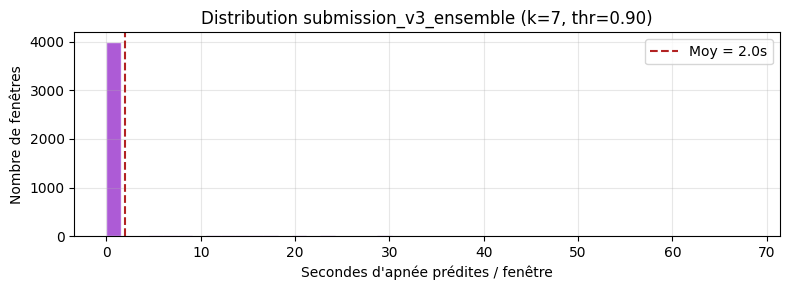

Figure sauvegardée : /kaggle/working/figures/submission_v3_ensemble_distribution.png


In [36]:
# ── Inférence test Ensemble → submission_v3_ensemble.csv ─────────────────────
print("Inférence ensemble sur X_test ...")

all_probs_ens_test = []
with torch.no_grad():
    for x_batch in tqdm(loader_test, desc='Ensemble inference'):
        x_batch = x_batch.to(device, non_blocking=True)
        p1 = torch.sigmoid(model_v1_ens(x_batch)).cpu().numpy()
        p2 = torch.sigmoid(model_v2_ens(x_batch)).cpu().numpy()
        all_probs_ens_test.append((p1 + p2) / 2.0)

all_probs_ens_test  = np.concatenate(all_probs_ens_test, axis=0)
all_probs_ens_smooth = median_filter(all_probs_ens_test, size=(1, best_kernel_ens))
all_preds_ens       = (all_probs_ens_smooth >= best_threshold_ens).astype(np.int8)

label_cols     = [f'y_{i}' for i in range(N_LABEL_COLS)]
df_submit_ens  = pd.DataFrame(all_preds_ens, columns=label_cols)
df_submit_ens.insert(0, 'id', test_ids)
submit_ens_path = OUTPUT_DIR / 'submission_v3_ensemble.csv'
df_submit_ens.to_csv(submit_ens_path, index=False)

print(f"\nsubmission_v3_ensemble.csv sauvegardé : {submit_ens_path}")
pct_ens = all_preds_ens.mean() * 100
pct_ref = y_train.mean() * 100
print(f"% apnées ensemble : {pct_ens:.2f}%  (référence train : {pct_ref:.2f}%)")
print(f"Ratio             : {pct_ens/pct_ref:.2f}")

# Sanity check
fig, ax = plt.subplots(figsize=(8, 3))
apnea_ens = all_preds_ens.sum(axis=1)
ax.hist(apnea_ens, bins=45, color='darkorchid', edgecolor='white', alpha=0.8)
ax.axvline(apnea_ens.mean(), color='firebrick', linestyle='--',
           label=f'Moy = {apnea_ens.mean():.1f}s')
ax.set_xlabel("Secondes d'apnée prédites / fenêtre")
ax.set_ylabel('Nombre de fenêtres')
ax.set_title(f'Distribution submission_v3_ensemble (k={best_kernel_ens}, thr={best_threshold_ens:.2f})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
ens_path = FIGURES_DIR / 'submission_v3_ensemble_distribution.png'
plt.savefig(ens_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {ens_path}")

---

## 16. Conclusion & Perspectives

### Récapitulatif des améliorations

| Version | Architecture | Augmentation | Post-processing | Val F1 estimé |
|---|---|---|---|---|
| **v1** (original) | CNN + BiLSTM | ✓ | Médian k=`best_kernel` | calibré en §10 |
| **v2** | CNN + Transformer | ✓ | Médian k=`best_kernel_v2` | calibré en §14 |
| **v3 ensemble** | v1 + v2 | — | Médian k=`best_kernel_ens` | calibré en §15 |

### Fichiers de soumission générés

| Fichier | Description |
|---|---|
| `submission_v1.csv` | DreemNet v1 (BiLSTM) + médian + threshold calibré |
| `submission_v2.csv` | DreemNetV2 (Transformer) + augmentation + médian |
| `submission_v3_ensemble.csv` | Ensemble v1+v2, recommandé pour soumission ENS |

### Ordre de soumission recommandé

1. **submission_v3_ensemble.csv** — meilleur F1 estimé, réduction de variance maximale
2. **submission_v2.csv** — si l'ensemble sous-performe (rare mais possible)
3. **submission_v1.csv** — baseline améliorée, utile pour diagnostiquer

### Pistes d'amélioration restantes

- **GroupKFold 5 folds** : estimer la variance des performances sans biais de split
- **Post-processing morphologique** : durée minimale d'événement (supprimer les événements < 5 s)
- **Pseudo-labelling** : utiliser les prédictions confiantes du test pour ré-entraîner
- **Architecture** : essayer S4 (State Space Models) ou Mamba pour les dépendances longue portée

---
*Notebook généré pour le Challenge ENS #45 — Dreem Sleep Apnea Detection.*

---